In [1]:
# Set up openjdk paths for spark

# for MacOS
import os
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/jdk-17.jdk/Contents/Home'
os.environ['PATH'] = f"{os.environ['JAVA_HOME']}/bin:{os.environ['PATH']}"

# Set up logging
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%H:%M:%S"
)

In [ ]:
# Imports
import json
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold

from pyinstrument import Profiler
from collections import defaultdict
from scipy.stats import spearmanr
from cider.schemas import (
    CallDataRecordData,
    AntennaData,
    MobileMoneyTransactionData,)
from cider.homelocation.schemas import GeographicUnit, GetHomeLocationAlgorithm
from cider.homelocation.core import get_home_locations
from cider.homelocation.plotting import make_location_map

from cider.featurizer.core import preprocess_data, featurize_all_data, featurize_cdr_data, featurize_mobile_money_data

/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'orm_mode' has been renamed to 'from_attributes'
  warnings.warn(message, UserWarning)
/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'orm_mode' has been renamed to 'from_attributes'
  warnings.warn(message, UserWarning)


# Reading synthetic data

In [3]:
malawi_file_path = '~/Documents/idinsight/projects/GiveDirectly/malawi/'
togo_file_path = '~/Documents/idinsight/projects/GiveDirectly/togo/'

malawi_cdr_df = pd.read_csv(malawi_file_path + 'synthetic_cdr.csv')
malawi_mobile_money_df = pd.read_csv(malawi_file_path + 'synthetic_new_mobile_money.csv')

togo_cdr_df = pd.read_csv(togo_file_path + 'synthetic_cdr.csv')
togo_mobile_money_df = pd.read_csv(togo_file_path + 'synthetic_mobile_money.csv')

In [4]:
print(malawi_cdr_df.shape)
malawi_cdr_df.head()

(6358, 18)


,txn_type,caller_msisdn,caller_network,recipient_msisdn,receiver_network,caller_antenna_id,recipient_antenna_id,intl_flag,network,recipient_prefix,caller_prefix,locationlac,locationci,recipient_lac_cell,caller_lac_cell,cdr_id,eventduration,datetime
0,call,sdv-id-npDTvM,NaN,AA87B89E774B3C2761970F92590F6935,NaN,5166990.0,2860088.0,NaN,Airtel,26599,26599,3008.0,41076,NaN,"7007, 8751",13269672,2625.0,2024-01-29 14:00:00
1,call,sdv-id-npDTvM,NaN,87CA294FE213CBDA474D15FF39332468,NaN,14602502.0,5478206.0,NaN,Airtel,26599,26599,3008.0,41076,NaN,"6008, 4295",15125677,2625.0,2024-01-29 14:00:00
2,call,sdv-id-npDTvM,NaN,AA87B89E774B3C2761970F92590F6935,NaN,16004334.0,6426342.0,NaN,Airtel,26599,26599,3008.0,41076,NaN,"770, 57113",6163253,2625.0,2024-01-29 14:00:00
3,call,sdv-id-npDTvM,NaN,9548142DDA96712EEAE5A92929A4690F,NaN,12525309.0,397688.0,NaN,Airtel,26599,26599,3008.0,41076,NaN,"9009, 37306",7715961,2625.0,2024-01-29 12:00:00
4,call,sdv-id-npDTvM,NaN,AB68DD70786498A43A9527EC88955A07,NaN,1261257.0,5043739.0,NaN,Airtel,26599,26599,3008.0,41076,NaN,"7007, 9703",11455473,2625.0,2024-01-29 14:00:00


In [5]:
print(malawi_mobile_money_df.shape)
malawi_mobile_money_df.head()

(56, 17)


,txn_type,sender_msisdn,recipient_msisdn,amount_mwk,txn_type_detailed,network,servicetype,sender_previous_balance,sender_post_balance,Unnamed: 0,phone_number,category,recipient_previous_balance,recipient_post_balance,servicetype_detailed,amount,datetime
0,NaN,sdv-id-lQLSml,NaN,1264.26,NaN,Airtel,cashout,6208.6317,132.7692,0.0,345-793-3801x25772,NaN,0.0,0.0,CASHOUT,259.263023,2024-01-09 12:00:00
1,NaN,sdv-id-Ofdlzs,NaN,1463.55,NaN,Airtel,cashout,2033.2326,3810.9202,0.0,563-882-7765,NaN,0.0,0.0,CASHOUT,106.668705,2024-01-09 09:00:00
2,NaN,sdv-id-tKRxmr,NaN,236.64,NaN,Airtel,cashout,10846.3403,5069.0213,0.0,469-214-5728,NaN,0.0,0.0,CASHOUT,236.624547,2024-01-11 06:00:00
3,NaN,sdv-id-UvnyGy,NaN,1311.24,NaN,Airtel,cashout,6862.8792,129.8098,0.0,749.834.1818,NaN,0.0,0.0,CASHOUT,264.838976,2024-01-09 12:00:00
4,NaN,sdv-id-HoitZp,NaN,120.35,NaN,Airtel,cashout,3136.4797,6117.8239,0.0,(484)732-0588x63200,NaN,0.0,0.0,CASHOUT,180.760432,2024-01-11 07:00:00


In [6]:
print('Malawi CDR data: intl_flag value counts')
print('------------------------------')
print(malawi_cdr_df['intl_flag'].value_counts(dropna=False))
print('Malawi CDR data: txn_type value counts')
print('------------------------------')
print(malawi_cdr_df['txn_type'].value_counts(dropna=False))

print('Malawi Mobile Money data: servicetype value counts')
print('------------------------------')
print(malawi_mobile_money_df['servicetype'].value_counts(dropna=False))

Malawi CDR data: intl_flag value counts
------------------------------
intl_flag
NaN    6358
Name: count, dtype: int64
Malawi CDR data: txn_type value counts
------------------------------
txn_type
call    6351
text       7
Name: count, dtype: int64
Malawi Mobile Money data: servicetype value counts
------------------------------
servicetype
cashout    50
p2b         6
Name: count, dtype: int64


In [7]:
# Preparing Malawi data
malawi_cdr_df['datetime'] = pd.to_datetime(malawi_cdr_df['datetime'])
malawi_mobile_money_df['datetime'] = pd.to_datetime(malawi_mobile_money_df['datetime'])

# togo_mobile_money_df['datetime'] = pd.to_datetime(togo_mobile_money_df['datetime'])

cdr_malawi_col_map = {
    'caller_msisdn': 'caller_id',
    'recipient_msisdn': 'recipient_id',
    'datetime': 'timestamp',
    'eventduration': 'duration',
    'txn_type': 'transaction_type',
    'intl_flag' : 'transaction_scope',
    'caller_antenna_id' : 'caller_antenna_id',
    'recipient_antenna_id' : 'recipient_antenna_id'
}

mob_money_malawi_col_map = {
    'sender_msisdn' : 'caller_id',
    'recipient_msisdn' : 'recipient_id',
    'datetime' : 'timestamp',
    'servicetype' : 'transaction_type',
    'amount' : 'amount', 
    'sender_previous_balance' : 'caller_balance_before',
    'sender_post_balance' : 'caller_balance_after',
    'recipient_previous_balance' : 'recipient_balance_before',
    'recipient_post_balance' : 'recipient_balance_after'
}

malawi_synthetic_data = {}
malawi_synthetic_data[CallDataRecordData] = malawi_cdr_df[cdr_malawi_col_map.keys()].rename(columns=cdr_malawi_col_map).copy()
malawi_synthetic_data[MobileMoneyTransactionData] = malawi_mobile_money_df[mob_money_malawi_col_map.keys()].rename(columns=mob_money_malawi_col_map).copy()

In [8]:
malawi_synthetic_data[CallDataRecordData].head()

,caller_id,recipient_id,timestamp,duration,transaction_type,transaction_scope,caller_antenna_id,recipient_antenna_id
0,sdv-id-npDTvM,AA87B89E774B3C2761970F92590F6935,2024-01-29 14:00:00,2625.0,call,NaN,5166990.0,2860088.0
1,sdv-id-npDTvM,87CA294FE213CBDA474D15FF39332468,2024-01-29 14:00:00,2625.0,call,NaN,14602502.0,5478206.0
2,sdv-id-npDTvM,AA87B89E774B3C2761970F92590F6935,2024-01-29 14:00:00,2625.0,call,NaN,16004334.0,6426342.0
3,sdv-id-npDTvM,9548142DDA96712EEAE5A92929A4690F,2024-01-29 12:00:00,2625.0,call,NaN,12525309.0,397688.0
4,sdv-id-npDTvM,AB68DD70786498A43A9527EC88955A07,2024-01-29 14:00:00,2625.0,call,NaN,1261257.0,5043739.0


In [9]:
malawi_synthetic_data[MobileMoneyTransactionData].head()    

,caller_id,recipient_id,timestamp,transaction_type,amount,caller_balance_before,caller_balance_after,recipient_balance_before,recipient_balance_after
0,sdv-id-lQLSml,NaN,2024-01-09 12:00:00,cashout,259.263023,6208.6317,132.7692,0.0,0.0
1,sdv-id-Ofdlzs,NaN,2024-01-09 09:00:00,cashout,106.668705,2033.2326,3810.9202,0.0,0.0
2,sdv-id-tKRxmr,NaN,2024-01-11 06:00:00,cashout,236.624547,10846.3403,5069.0213,0.0,0.0
3,sdv-id-UvnyGy,NaN,2024-01-09 12:00:00,cashout,264.838976,6862.8792,129.8098,0.0,0.0
4,sdv-id-HoitZp,NaN,2024-01-11 07:00:00,cashout,180.760432,3136.4797,6117.8239,0.0,0.0


In [10]:
print(f'Caller ids in CDR data: {malawi_synthetic_data[CallDataRecordData]["caller_id"].nunique()}')
print(f'Caller ids in Mobile Money data: {malawi_synthetic_data[MobileMoneyTransactionData]["caller_id"].nunique()}')

Caller ids in CDR data: 1157
Caller ids in Mobile Money data: 55


In [11]:
togo_mobile_money_df.head()

,txn_type,caller_id,recipient_id,amount,timestamp
0,Cashout,sdv-id-emGaZc,sdv-id-wMBDGm,3000.000000,2018-10-24 08:00:00
1,Cashout,sdv-id-SFHsHi,sdv-id-bYYjWL,5000.000000,2018-10-19 04:00:00
2,Cashout,sdv-id-sWarlO,sdv-id-PUTceI,10000.000000,2018-10-24 07:00:00
3,Cashout,sdv-id-HFKERg,sdv-id-tTkgYX,5000.000000,2018-10-17 05:00:00
4,Cashout,sdv-id-cPnJwO,sdv-id-nrPnEA,46681.535778,2018-10-26 05:00:00


In [12]:
# Preparing Togo data
togo_cdr_df['datetime'] = pd.to_datetime(togo_cdr_df['datetime'])
# based on assumption that 'international' column is binary with 1 for international and 0 for domestic
togo_cdr_df['international'] = np.where(togo_cdr_df['international'] == 1, 'international', 'domestic')
# no recepient antenna id column in togo cdr data, so create a placeholder column with null values
togo_cdr_df['recipient_antenna_id'] = None

# Togo mobile money data is missing balance before and after columns, create placeholder columns with null values
togo_mobile_money_df['timestamp'] = pd.to_datetime(togo_mobile_money_df['timestamp'])
togo_mobile_money_df['caller_balance_before'] = None
togo_mobile_money_df['caller_balance_after'] = None
togo_mobile_money_df['recipient_balance_before'] = None
togo_mobile_money_df['recipient_balance_after'] = None

cdr_togo_col_map = {
    'caller_msisdn': 'caller_id',
    'recipient_msisdn': 'recipient_id',
    'datetime': 'transaction',
    'duration': 'duration',
    'txn_type': 'transaction_type',
    'international' : 'transaction_scope',
    'caller_antenna_id' : 'caller_antenna_id',
    'recipient_antenna_id' : 'recipient_antenna_id'
}

mob_money_togo_col_map = {
    'caller_id' : 'caller_id',
    'recipient_id' : 'recipient_id',
    'timestamp' : 'timestamp',
    'txn_type' : 'transaction_type',
    'amount' : 'amount', 
    'caller_balance_before' : 'caller_balance_before',
    'caller_balance_after' : 'caller_balance_after',
    'recipient_balance_before' : 'recipient_balance_before',
    'recipient_balance_after' : 'recipient_balance_after'
}

togo_synthetic_data = {}
togo_synthetic_data[CallDataRecordData] = togo_cdr_df[cdr_togo_col_map.keys()].rename(columns=cdr_togo_col_map).copy()
togo_synthetic_data[MobileMoneyTransactionData] = togo_mobile_money_df[mob_money_togo_col_map.keys()].rename(columns=mob_money_togo_col_map).copy()

In [13]:
togo_synthetic_data[MobileMoneyTransactionData]

,caller_id,recipient_id,timestamp,transaction_type,amount,caller_balance_before,caller_balance_after,recipient_balance_before,recipient_balance_after
0,sdv-id-emGaZc,sdv-id-wMBDGm,2018-10-24 08:00:00,Cashout,3000.000000,None,None,None,None
1,sdv-id-SFHsHi,sdv-id-bYYjWL,2018-10-19 04:00:00,Cashout,5000.000000,None,None,None,None
2,sdv-id-sWarlO,sdv-id-PUTceI,2018-10-24 07:00:00,Cashout,10000.000000,None,None,None,None
3,sdv-id-HFKERg,sdv-id-tTkgYX,2018-10-17 05:00:00,Cashout,5000.000000,None,None,None,None
4,sdv-id-cPnJwO,sdv-id-nrPnEA,2018-10-26 05:00:00,Cashout,46681.535778,None,None,None,None
...,...,...,...,...,...,...,...,...,...
325,sdv-id-OCEfqi,sdv-id-MmffTJ,2018-10-15 07:00:00,Cashout,5517.243972,None,None,None,None
326,sdv-id-nCWDjz,sdv-id-xgoWAy,2018-10-22 06:00:00,Cashout,2224.417724,None,None,None,None
327,sdv-id-DPZqyJ,sdv-id-DzMobg,2018-10-19 07:00:00,Cashout,5000.000000,None,None,None,None
328,sdv-id-EFAHoN,sdv-id-dkqZsa,2018-10-24 08:00:00,Cashout,3000.000000,None,None,None,None


In [14]:
togo_synthetic_data[CallDataRecordData]

,caller_id,recipient_id,transaction,duration,transaction_type,transaction_scope,caller_antenna_id,recipient_antenna_id
0,sdv-id-emGaZc,sdv-id-ZgcgOA,2018-10-22 10:00:00,NaN,text,domestic,615-01-00090-00494,None
1,sdv-id-emGaZc,sdv-id-Rccrfh,2018-10-09 20:00:00,40.725194,call,domestic,615-01-00203-07803,None
2,sdv-id-emGaZc,sdv-id-MWwjIv,2018-10-10 08:00:00,NaN,text,domestic,615-01-00210-07953,None
3,sdv-id-OoYTFU,sdv-id-yyWUTA,2018-10-24 11:00:00,50.181420,call,domestic,9581,None
4,sdv-id-OoYTFU,sdv-id-YffiZZ,2018-10-12 11:00:00,NaN,text,domestic,615-01-00230-06383,None
...,...,...,...,...,...,...,...,...
13869,sdv-id-fXEoDt,sdv-id-pJdVpw,2018-10-16 06:00:00,24.542429,call,domestic,615-01-00439-91157,None
13870,sdv-id-fXEoDt,sdv-id-QXAUSJ,2018-10-17 16:00:00,452.508398,call,domestic,615-01-00231-09581,None
13871,sdv-id-fXEoDt,sdv-id-sxBHPS,2018-10-12 20:00:00,NaN,text,domestic,615031222124,None
13872,sdv-id-fXEoDt,sdv-id-IrwpQb,2018-10-10 12:00:00,NaN,text,domestic,23201,None


# Preprocessing data

In [13]:
keep_optional_columns = False # Remove optional fields to reduce number of features
shapefile_gdf = None # Since we're not using geographic features for this analysis

# Set parameters for home location inference
# geographic_unit = GeographicUnit.SHAPEFILE
# algorithm = GetHomeLocationAlgorithm.COUNT_DAYS

# Set parameters for preprocessing
filter_start_date = datetime.strptime("2022-01-05", "%Y-%m-%d")
filter_end_date = datetime.strptime("2025-01-25", "%Y-%m-%d")
# spammer_threshold = 1.75
spammer_threshold = 10
# outlier_day_z_score_threshold = 2.0
outlier_day_z_score_threshold = 4.0

# Set parameters for featurizer
max_wait_for_convo_in_seconds = 3600
pareto_threshold = 0.8

synthetic_data = malawi_synthetic_data.copy()

When using  spammer_threshold = 1.75 and outlier_day_z_threshold = 2.0, 

Only 55 caller ids with MobileMoneyTransactionData (before preprocessing). 

After preprocessing, only 25 caller ids have both MobileMoneyTransaction and CDR features.

Should we consider making preprocessing more lenient?
(I will try using lenient spammer_threshold and outlier_day_z_score_threshold first.)

In [14]:
if keep_optional_columns:
# Set parameters for home location inference
    geographic_unit = GeographicUnit.SHAPEFILE
    algorithm = GetHomeLocationAlgorithm.COUNT_DAYS

    # Infer home locations
    homes_df = get_home_locations(
        cdr_data=synthetic_data[CallDataRecordData],
        antenna_data=synthetic_data[AntennaData],
        shapefile_data=shapefile_gdf,
        geographic_unit=geographic_unit,
        algorithm=algorithm,
        additional_columns_to_keep=[],
    )

    # Merge home locations with antenna data for plotting
    homes_with_antenna_df = homes_df.merge(
        synthetic_data[AntennaData],
        left_on="caller_antenna_id",
        right_on="antenna_id",
        how="left")

    # Convert to GeoDataFrame
    homes_with_antenna_gdf = gpd.GeoDataFrame(
        homes_with_antenna_df,
        geometry=gpd.points_from_xy(
            x=homes_with_antenna_df['longitude'],
            y=homes_with_antenna_df['latitude'])
    ).set_crs(epsg=4326)

    # Plot home locations
    make_location_map(
        inferred_home_locations=homes_with_antenna_gdf,
        boundaries_shapefile=shapefile_gdf,
        column_to_plot_label="caller_antenna_id",
        column_to_plot_markersize=algorithm.value,
    )

else:
    logging.info("Skipping home location inference and plotting since optional columns were not included in synthetic data")

# Preprocess data: filtering, spammer removal, outlier day removal
preprocessed_data = preprocess_data(
    data_dict=synthetic_data,
    filter_start_date=filter_start_date,
    filter_end_date=filter_end_date,
    spammer_threshold=spammer_threshold,
    outlier_day_z_score_threshold=outlier_day_z_score_threshold,
)

10:11:30 | INFO | root | Skipping home location inference and plotting since optional columns were not included in synthetic data
10:11:30 | INFO | cider.featurizer.core | Preprocessing data
10:11:30 | INFO | cider.featurizer.core | Preprocessing data for schema: CallDataRecordData
10:11:30 | WARNING | cider.featurizer.core | MobileDataUsageData not found in data_dict. Skipping preprocessing for this schema.
10:11:30 | INFO | cider.featurizer.core | Preprocessing data for schema: MobileMoneyTransactionData
10:11:30 | WARNING | cider.featurizer.core | RechargeData not found in data_dict. Skipping preprocessing for this schema.


In [15]:
call_ids = malawi_synthetic_data[CallDataRecordData]['caller_id'].unique()

print('Before preprocessing')
print('------------------------------')
print(f'Num of caller ids with MobileMoneyTransactionData: {malawi_synthetic_data[MobileMoneyTransactionData]["caller_id"].nunique()}')
print(f'Num of caller ids with CallDataRecordData: {malawi_synthetic_data[CallDataRecordData]["caller_id"].nunique()}')
# number of caller ids in mobile money data that are also in call data
print(f'Num of caller ids with both data: {len(set(malawi_synthetic_data[MobileMoneyTransactionData]["caller_id"].unique()).intersection(call_ids))}')

call_ids = preprocessed_data[CallDataRecordData]['caller_id'].unique()
print('After preprocessing:')
print('------------------------------')
print(f'Num of caller ids with MobileMoneyTransactionData: {preprocessed_data[MobileMoneyTransactionData]["caller_id"].nunique()}')
print(f'Num of caller ids with CallDataRecordData: {preprocessed_data[CallDataRecordData]["caller_id"].nunique()}')
print(f'Num of caller ids with both data: {len(set(preprocessed_data[MobileMoneyTransactionData]["caller_id"].unique()).intersection(call_ids))}')

Before preprocessing
------------------------------
Num of caller ids with MobileMoneyTransactionData: 55
Num of caller ids with CallDataRecordData: 1157
Num of caller ids with both data: 55
After preprocessing:
------------------------------
Num of caller ids with MobileMoneyTransactionData: 51
Num of caller ids with CallDataRecordData: 1021
Num of caller ids with both data: 51


In [15]:
preprocessed_data[CallDataRecordData].head()

,caller_id,recipient_id,timestamp,duration,transaction_type,transaction_scope,caller_antenna_id,recipient_antenna_id,day
0,sdv-id-npDTvM,AA87B89E774B3C2761970F92590F6935,2024-01-29 14:00:00,2625.0,call,NaN,5166990.0,2860088.0,2024-01-29
1,sdv-id-npDTvM,87CA294FE213CBDA474D15FF39332468,2024-01-29 14:00:00,2625.0,call,NaN,14602502.0,5478206.0,2024-01-29
2,sdv-id-npDTvM,AA87B89E774B3C2761970F92590F6935,2024-01-29 14:00:00,2625.0,call,NaN,16004334.0,6426342.0,2024-01-29
3,sdv-id-npDTvM,9548142DDA96712EEAE5A92929A4690F,2024-01-29 12:00:00,2625.0,call,NaN,12525309.0,397688.0,2024-01-29
4,sdv-id-npDTvM,AB68DD70786498A43A9527EC88955A07,2024-01-29 14:00:00,2625.0,call,NaN,1261257.0,5043739.0,2024-01-29


# Featurizer

In [16]:

if keep_optional_columns:
    logging.info("Proceeding with featurization since optional columns were included in synthetic data")
    # Prepare antenna_data
    antenna_gdf = gpd.GeoDataFrame(
        synthetic_data[AntennaData],
        geometry=gpd.points_from_xy(
            x=synthetic_data[AntennaData]['longitude'],
            y=synthetic_data[AntennaData]['latitude'])
    ).set_crs(epsg=4326)
    antennas_merged_shp = gpd.sjoin(antenna_gdf, shapefile_gdf, how='left', predicate='within')[['antenna_id', 'region']]
    antennas_merged_shp.region.fillna('Unknown', inplace=True)
    antennas_df = antennas_merged_shp.merge(
        synthetic_data[AntennaData],
        on="antenna_id")

    preprocessed_data[AntennaData] = antennas_df

# Featurize data
logging.info("Featurizing CDR data")
malawi_cdr_features_df = featurize_cdr_data(
        preprocessed_data[CallDataRecordData],
        preprocessed_data[AntennaData] if AntennaData in preprocessed_data else None,
        max_wait_for_convo_in_seconds,
        pareto_threshold,
    )

logging.info("Featurizing mobile money data")
malawi_mobile_money_features_df = featurize_mobile_money_data(
    preprocessed_data[MobileMoneyTransactionData]
)

# Featurize all data
# features_df = featurize_all_data(
#     preprocessed_data=preprocessed_data,
#     max_wait_for_convo_in_seconds=max_wait_for_convo_in_seconds,
#     pareto_threshold=pareto_threshold,
# )


10:11:30 | INFO | root | Featurizing CDR data
26/03/05 10:11:32 WARN Utils: Your hostname, Vivians-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.1.7 instead (on interface en0)
26/03/05 10:11:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 10:11:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
10:11:34 | INFO | cider.featurizer.core | Identifying daytime and weekend interactions
10:11:34 | INFO | cider.featurizer.core | Swapping caller and recipient IDs for recipient-centric view
10:11:34 | INFO | cider.featurizer.core | Identifying and tagging conversations
10:11:34 | INFO | cider.featurizer.core | Calculating active days per caller
10:11:34 | INFO | cider.featurizer.core | Calculating number of unique contacts per cal

In [17]:
malawi_cdr_features_df.head()

,caller_id,active_days_all,active_days_weekday,active_days_weekend,active_days_day,active_days_night,active_days_weekday_day,active_days_weekday_night,active_days_weekend_day,active_days_weekend_night,...,text_weekday_num_interactions,call_weekday_num_interactions,text_weekend_num_interactions,call_weekend_num_interactions,text_incoming_num_interactions,call_incoming_num_interactions,text_outgoing_num_interactions,call_outgoing_num_interactions,text_num_interactions,call_num_interactions
0,0D16238744BBB8DF5A09A564A2F58568,4,4,0,4,1,4,1,0,0,...,0.0,30.0,0.0,0.0,0.0,30.0,0.0,NaN,0.0,30.0
1,19BEF3A49466F59EB5C8A2ADA3D0D21A,2,2,0,2,1,2,1,0,0,...,0.0,7.0,0.0,0.0,0.0,7.0,0.0,NaN,0.0,7.0
2,1AB0EDC036D0D2C183D9EF65362FACD5,3,3,0,3,0,3,0,0,0,...,0.0,4.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,4.0
3,3317A62EAC964BE179ACDE6411334D80,3,3,0,3,1,3,1,0,0,...,0.0,27.0,0.0,0.0,0.0,27.0,0.0,NaN,0.0,27.0
4,368FF0D0B7A0A65B9BC538EE45654884,1,1,0,1,0,1,0,0,0,...,0.0,2.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,2.0


In [21]:
malawi_cdr_features_df.to_csv(malawi_file_path + 'cdr_features.csv', index=False)
malawi_mobile_money_features_df.to_csv(malawi_file_path + 'mobile_money_features.csv', index=False)

In [20]:
malawi_mobile_money_features_df.head()

,caller_id,cashout_first(mean_amount),cashout_first(min_amount),cashout_first(max_amount),cashout_first(std_amount),p2b_first(mean_amount),p2b_first(min_amount),p2b_first(max_amount),p2b_first(std_amount),mean_amount,...,p2b_first(max_balance_before),p2b_first(std_balance_before),mean_balance_after,min_balance_after,max_balance_after,std_balance_after,mean_balance_before,min_balance_before,max_balance_before,std_balance_before
0,NaN,204.927563,102.171228,554.469290,91.384493,266.952354,161.432901,383.857723,91.160773,208.724999,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0
1,sdv-id-0Bbacw,NaN,NaN,NaN,NaN,65.241571,65.241571,65.241571,0.000000,65.241571,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0
2,sdv-id-ARsFVA,223.902336,223.902336,223.902336,0.000000,NaN,NaN,NaN,NaN,223.902336,...,NaN,NaN,757.5355,757.5355,757.5355,0.0,3079.0997,3079.0997,3079.0997,0.0
3,sdv-id-BmzKNJ,344.999528,344.999528,344.999528,0.000000,NaN,NaN,NaN,NaN,344.999528,...,NaN,NaN,1780.2893,1780.2893,1780.2893,0.0,4453.0192,4453.0192,4453.0192,0.0
4,sdv-id-CHPHpJ,117.842096,117.842096,117.842096,0.000000,NaN,NaN,NaN,NaN,117.842096,...,NaN,NaN,5777.3730,5777.3730,5777.3730,0.0,5732.8895,5732.8895,5732.8895,0.0


In [17]:
malawi_features_df = malawi_cdr_features_df.merge(malawi_mobile_money_features_df, on='caller_id', how='outer')
print(malawi_features_df.shape)
malawi_features_df

(1224, 704)


,caller_id,active_days_all,active_days_weekday,active_days_weekend,active_days_day,active_days_night,active_days_weekday_day,active_days_weekday_night,active_days_weekend_day,active_days_weekend_night,...,p2b_first(max_balance_before),p2b_first(std_balance_before),mean_balance_after,min_balance_after,max_balance_after,std_balance_after,mean_balance_before,min_balance_before,max_balance_before,std_balance_before
0,0D16238744BBB8DF5A09A564A2F58568,4.0,4.0,0.0,4.0,1.0,4.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19BEF3A49466F59EB5C8A2ADA3D0D21A,2.0,2.0,0.0,2.0,1.0,2.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1AB0EDC036D0D2C183D9EF65362FACD5,3.0,3.0,0.0,3.0,0.0,3.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3317A62EAC964BE179ACDE6411334D80,3.0,3.0,0.0,3.0,1.0,3.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,368FF0D0B7A0A65B9BC538EE45654884,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219,sdv-id-zkkjmA,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1221,sdv-id-0Bbacw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1222,sdv-id-OlFBtI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# label data

In [18]:
malawi_consumption_df = pd.read_csv(malawi_file_path + 'synthetic_consumption.csv')
malawi_consumption_df.head()

,phone_number,consumption,asset_index,num_members
0,sdv-id-npDTvM,1909.273525,0.087504,3.0
1,sdv-id-RudWeF,1058.166963,0.081180,5.0
2,sdv-id-aIOlKX,1407.465981,0.097257,4.0
3,sdv-id-OXabRH,839.536492,0.092715,5.0
4,sdv-id-ufbzxd,6395.837177,0.101676,5.0


<Axes: xlabel='consumption', ylabel='Count'>

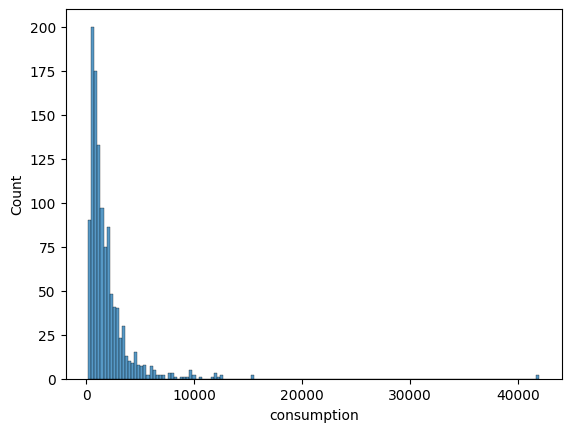

In [19]:
sns.histplot(data=malawi_consumption_df, x='consumption')

<Axes: ylabel='consumption'>

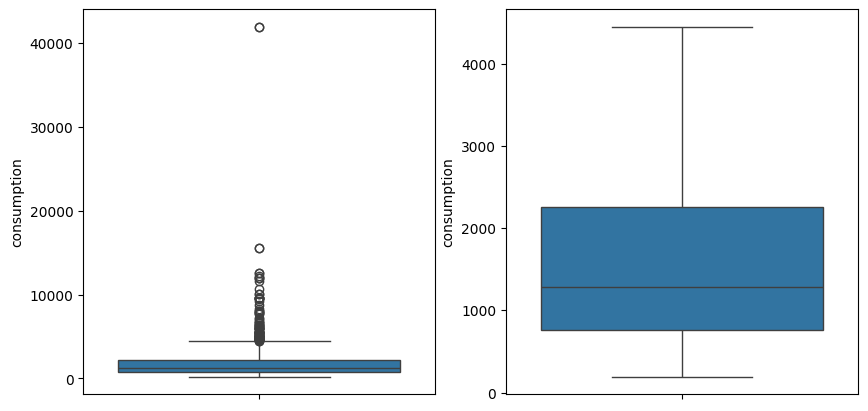

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(data=malawi_consumption_df, y='consumption', ax=axes[0])
sns.boxplot(data=malawi_consumption_df, y='consumption', ax=axes[1], showfliers=False)

In [22]:
merged_df = malawi_consumption_df.merge(malawi_features_df, how='left', left_on='phone_number', right_on='caller_id')
merged_df[malawi_cdr_features_df.columns].notna().sum()

caller_id                         1021
active_days_all                   1021
active_days_weekday               1021
active_days_weekend               1021
active_days_day                   1021
                                  ... 
call_incoming_num_interactions       5
text_outgoing_num_interactions    1021
call_outgoing_num_interactions    1021
text_num_interactions             1021
call_num_interactions             1021
Length: 664, dtype: int64

In [25]:
merged_df[malawi_mobile_money_features_df.columns].notna().sum()

caller_id                                   1021
cashout_first(mean_amount)                    46
cashout_first(min_amount)                     46
cashout_first(max_amount)                     46
cashout_first(std_amount)                     46
p2b_first(mean_amount)                         6
p2b_first(min_amount)                          6
p2b_first(max_amount)                          6
p2b_first(std_amount)                          6
mean_amount                                   51
min_amount                                    51
max_amount                                    51
std_amount                                    51
cashout_first(num_transactions)               46
cashout_first(num_unique_correspondents)      46
p2b_first(num_transactions)                    6
p2b_first(num_unique_correspondents)           6
cashout_first(mean_balance_after)             46
cashout_first(min_balance_after)              46
cashout_first(max_balance_after)              46
cashout_first(std_ba

## Correlation with consumption data

In [21]:
# get summary statistics for each features and get features with nonzero variance (std > 0)
feature_sum_stats = malawi_features_df.drop(columns=['caller_id']).describe().T.reset_index().rename(columns={'index': 'feature'})
temp_features = feature_sum_stats[feature_sum_stats['std'] > 0]['feature'].tolist()
len(temp_features)

358

In [24]:
exclude_columns = ['consumption', 'phone_number', 'caller_id', 'asset_index', 'num_members']

# Drop features with zero variance and filter to rows with caller id available in features data
filt_merged_df = merged_df[merged_df['caller_id'].notna()].copy()
print(filt_merged_df.shape)

# get statistics for each feature
feature_sum_stats = filt_merged_df.drop(columns=exclude_columns).describe().T.reset_index().rename(columns={'index': 'feature'})
filtered_non_zero_var_features = feature_sum_stats[feature_sum_stats['std'] > 0]['feature'].tolist()
filt_merged_df = filt_merged_df[filtered_non_zero_var_features + exclude_columns].copy()
print(f'Num of features with nonzero variance: {len(filtered_non_zero_var_features)}')
print(filt_merged_df.shape)

# get availability for each feature
availability = filt_merged_df.notna().sum() / len(filt_merged_df)
availability = availability.reset_index(name='availability').rename(columns={'index': 'feature'})
availability_count = filt_merged_df.notna().sum()
availability_count = availability_count.reset_index(name='availability_count').rename(columns={'index': 'feature'})

# get correlation of each feature with consumption
correlation = filt_merged_df.drop(columns=['phone_number', 'caller_id', 'asset_index', 'num_members']).corr()['consumption']
correlation = correlation.reset_index(name='correlation_with_consumption').rename(columns={'index': 'feature'})
correlation = correlation[correlation['feature'] != 'consumption'] # drop correlation of consumption with itself
# merge 
avail_corr_df = availability.merge(availability_count, on='feature', how='left')
avail_corr_df = avail_corr_df.merge(correlation, on='feature', how='left')
avail_corr_df['abs_correlation'] = avail_corr_df['correlation_with_consumption'].abs()



(1021, 708)
Num of features with nonzero variance: 329
(1021, 334)


In [27]:
avail_corr_df[avail_corr_df['correlation_with_consumption'].isna()]

,feature,availability,availability_count,correlation_with_consumption,abs_correlation
329,consumption,1.0,1021,NaN,NaN
330,phone_number,1.0,1021,NaN,NaN
331,caller_id,1.0,1021,NaN,NaN
332,asset_index,1.0,1021,NaN,NaN
333,num_members,1.0,1021,NaN,NaN


In [28]:
# sort by correlation with consumption
avail_corr_df.sort_values('abs_correlation', ascending=False).head(20)

,feature,availability,availability_count,correlation_with_consumption,abs_correlation
315,p2b_first(mean_balance_after),0.005877,6,0.850766,0.850766
316,p2b_first(min_balance_after),0.005877,6,0.850766,0.850766
317,p2b_first(max_balance_after),0.005877,6,0.850766,0.850766
304,p2b_first(max_amount),0.005877,6,-0.662208,0.662208
303,p2b_first(min_amount),0.005877,6,-0.662208,0.662208
302,p2b_first(mean_amount),0.005877,6,-0.662208,0.662208
320,p2b_first(max_balance_before),0.005877,6,-0.614762,0.614762
319,p2b_first(min_balance_before),0.005877,6,-0.614762,0.614762
318,p2b_first(mean_balance_before),0.005877,6,-0.614762,0.614762
67,kurtosis_duration,0.011753,12,0.474143,0.474143


In [29]:
# sort by availability and absolute correlation with consumption
avail_corr_df.sort_values(['availability', 'abs_correlation'], ascending=[False, False]).dropna(subset=['correlation_with_consumption']).head(20)

,feature,availability,availability_count,correlation_with_consumption,abs_correlation
167,call_weekday_nighttime_std_interaction_count,1.0,1021,0.035870,0.035870
169,call_nighttime_std_interaction_count,1.0,1021,0.035870,0.035870
23,weekday_nighttime_min_duration,1.0,1021,0.035186,0.035186
31,weekday_nighttime_median_duration,1.0,1021,0.035186,0.035186
39,nighttime_min_duration,1.0,1021,0.035186,0.035186
45,nighttime_median_duration,1.0,1021,0.035186,0.035186
20,weekday_nighttime_mean_duration,1.0,1021,0.035183,0.035183
37,nighttime_mean_duration,1.0,1021,0.035183,0.035183
26,weekday_nighttime_max_duration,1.0,1021,0.035181,0.035181
41,nighttime_max_duration,1.0,1021,0.035181,0.035181


Text(0, 0.5, 'Absolute Correlation with Consumption')

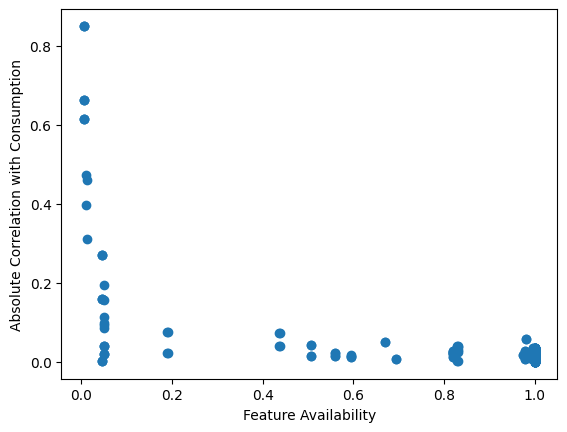

In [30]:
plt.scatter(avail_corr_df['availability'], avail_corr_df['abs_correlation'])
plt.xlabel('Feature Availability')
plt.ylabel('Absolute Correlation with Consumption')

## EDA

In [205]:
cdr_filtered_non_zero_var_features = list(set(filtered_non_zero_var_features).intersection(set(malawi_cdr_features_df.columns)))
print(f'Filtered CDR features with nonzero variance: {len(cdr_filtered_non_zero_var_features)}')
mm_filtered_non_zero_var_features = list(set(filtered_non_zero_var_features).intersection(set(malawi_mobile_money_features_df.columns)))
print(f'Filtered Mobile Money features with nonzero variance: {len(mm_filtered_non_zero_var_features)}')

Filtered CDR features with nonzero variance: 299
Filtered Mobile Money features with nonzero variance: 30


In [44]:
cdr_features_sum_stats = filt_merged_df[list(cdr_filtered_non_zero_var_features)].describe().T
cdr_features_sum_stats['max'].describe()
ordered = list(cdr_features_sum_stats.sort_values('std', ascending=False).index)

In [45]:
len(ordered)/2

149.5

### CDR boxplots

In [ ]:
fig, axs = plt.subplots(int(np.ceil(len(ordered)/3)), 3, figsize=[10, 100])
for i, feature in enumerate(ordered):
    sns.boxplot(data=filt_merged_df, x=feature, orient='h', ax=axs[i//3, i%3])
plt.tight_layout()
plt.title('Boxplots of CDR features with nonzero variance, ordered by standard deviation')

In [ ]:
fig, axs = plt.subplots(int(np.ceil(len(ordered)/3)), 3, figsize=[10, 100])
for i, feature in enumerate(ordered):
    sns.boxplot(data=filt_merged_df, x=feature, orient='h', ax=axs[i//3, i%3], showfliers=False)
plt.tight_layout()
plt.title('Boxplots of CDR features with nonzero variance, ordered by standard deviation, removed outliers')

In [ ]:
# reading selected features from json file created in section below
raw_path = '~/Documents/idinsight/projects/GiveDirectly/synthetic_data_analysis/recommended_features.json'
expanded_path = os.path.expanduser(raw_path)

with open(expanded_path, 'r') as f:
    selected_features = json.load(f) 

In [91]:
malawi_cdr_features_df[selected_features['cdr']].head()

,call_weekday_daytime_min_inter_event_time,call_weekday_min_inter_event_time,call_weekday_nighttime_max_inter_event_time,call_weekday_nighttime_mean_inter_event_time,call_weekday_nighttime_median_inter_event_time,call_weekday_nighttime_min_inter_event_time,call_weekday_nighttime_std_inter_event_time,weekday_nighttime_mean_duration,weekday_nighttime_min_duration,call_nighttime_mean_inter_event_time,...,weekday_call_num_unique_contacts,call_weekday_min_interaction_count,call_daytime_std_interaction_count,call_weekday_daytime_std_interaction_count,text_weekday_daytime_median_inter_event_time,weekday_mean_duration,call_min_interaction_count,weekday_daytime_mean_duration,weekday_max_duration,weekday_daytime_median_duration
0,0.0,0.0,14400.0,1800.0,0.0,0.0,4762.35236,2625.0,2625.0,1800.0,...,24.0,1.0,0.372678,0.372678,0.0,2275.000000,1.0,2125.00,2625.0,2625.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,2625.0,2625.0,0.0,...,7.0,1.0,0.000000,0.000000,0.0,2625.000000,1.0,2625.00,2625.0,2625.0
2,21600.0,21600.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,4.0,1.0,0.000000,0.000000,0.0,1968.750000,1.0,1968.75,2625.0,2625.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,2625.0,2625.0,0.0,...,20.0,1.0,1.007687,1.007687,0.0,1555.555556,1.0,1470.00,2625.0,2625.0
4,10800.0,10800.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,2.0,1.0,0.000000,0.000000,0.0,2625.000000,1.0,2625.00,2625.0,2625.0


<Axes: >

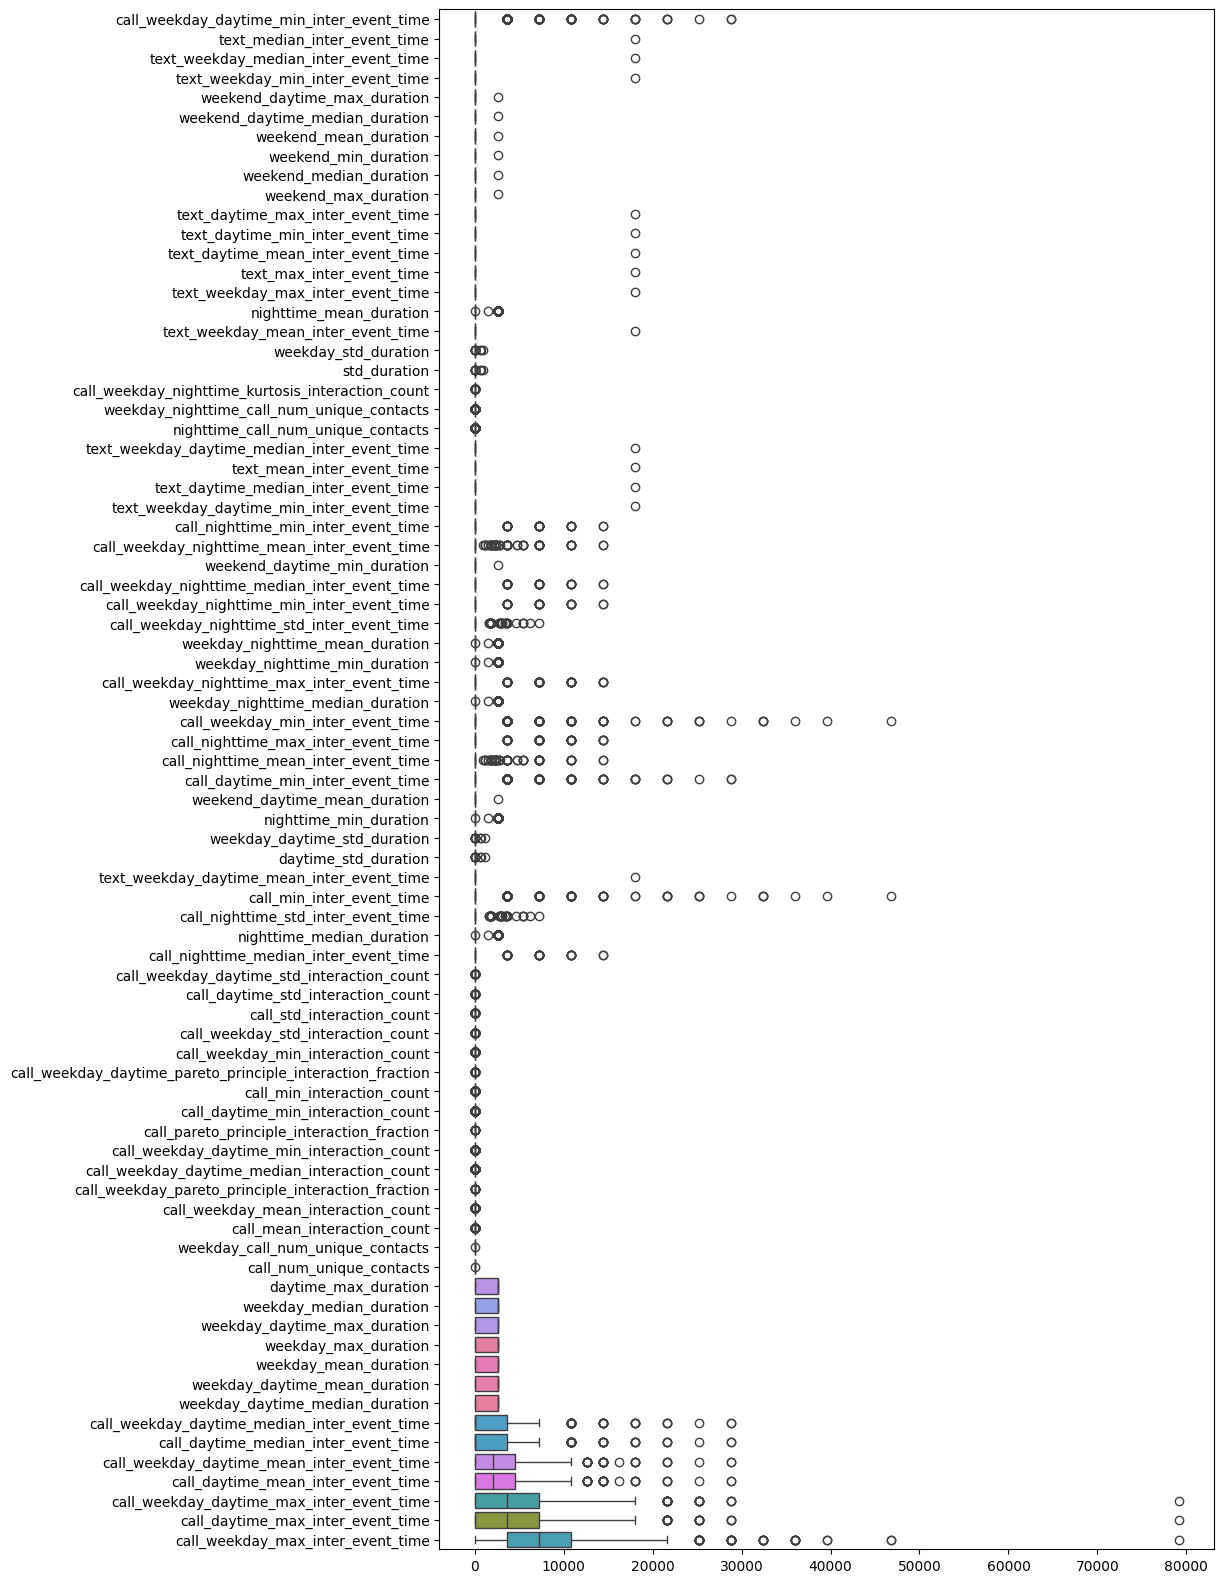

In [188]:
plt.figure(figsize=(10, 20))
# ordered = list(malawi_cdr_features_df[selected_features['cdr']].describe().T.sort_values(['50%', '75%'], ascending=[True, True]).index)
ordered = list(filt_merged_df[selected_features['cdr']].describe().T.sort_values(['75%'], ascending=[True]).index)
sns.boxplot(data=filt_merged_df[selected_features['cdr']], orient='h', order=ordered)

<Axes: >

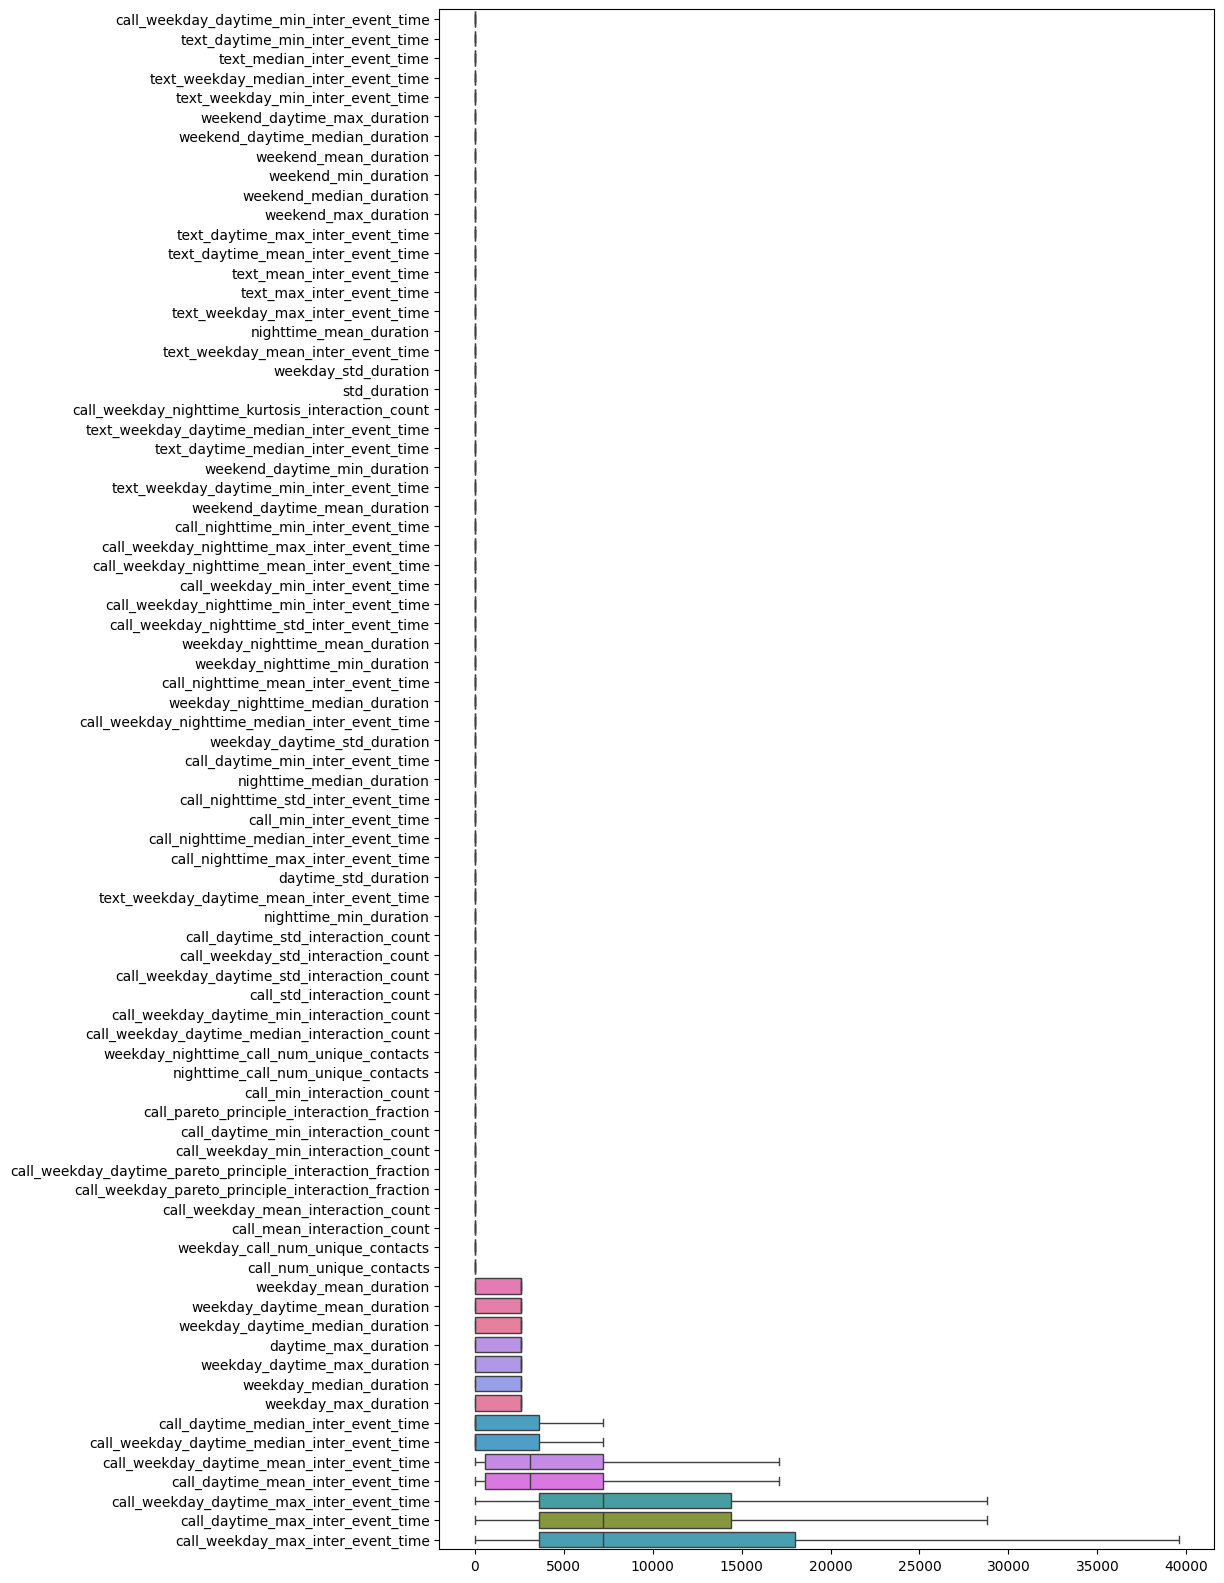

In [140]:
plt.figure(figsize=(10, 20))
sns.boxplot(data=malawi_cdr_features_df[selected_features['cdr']], orient='h', order=ordered, showfliers=False)

Text(0.5, 1.0, 'Fig 1: CDR features, removed outliers')

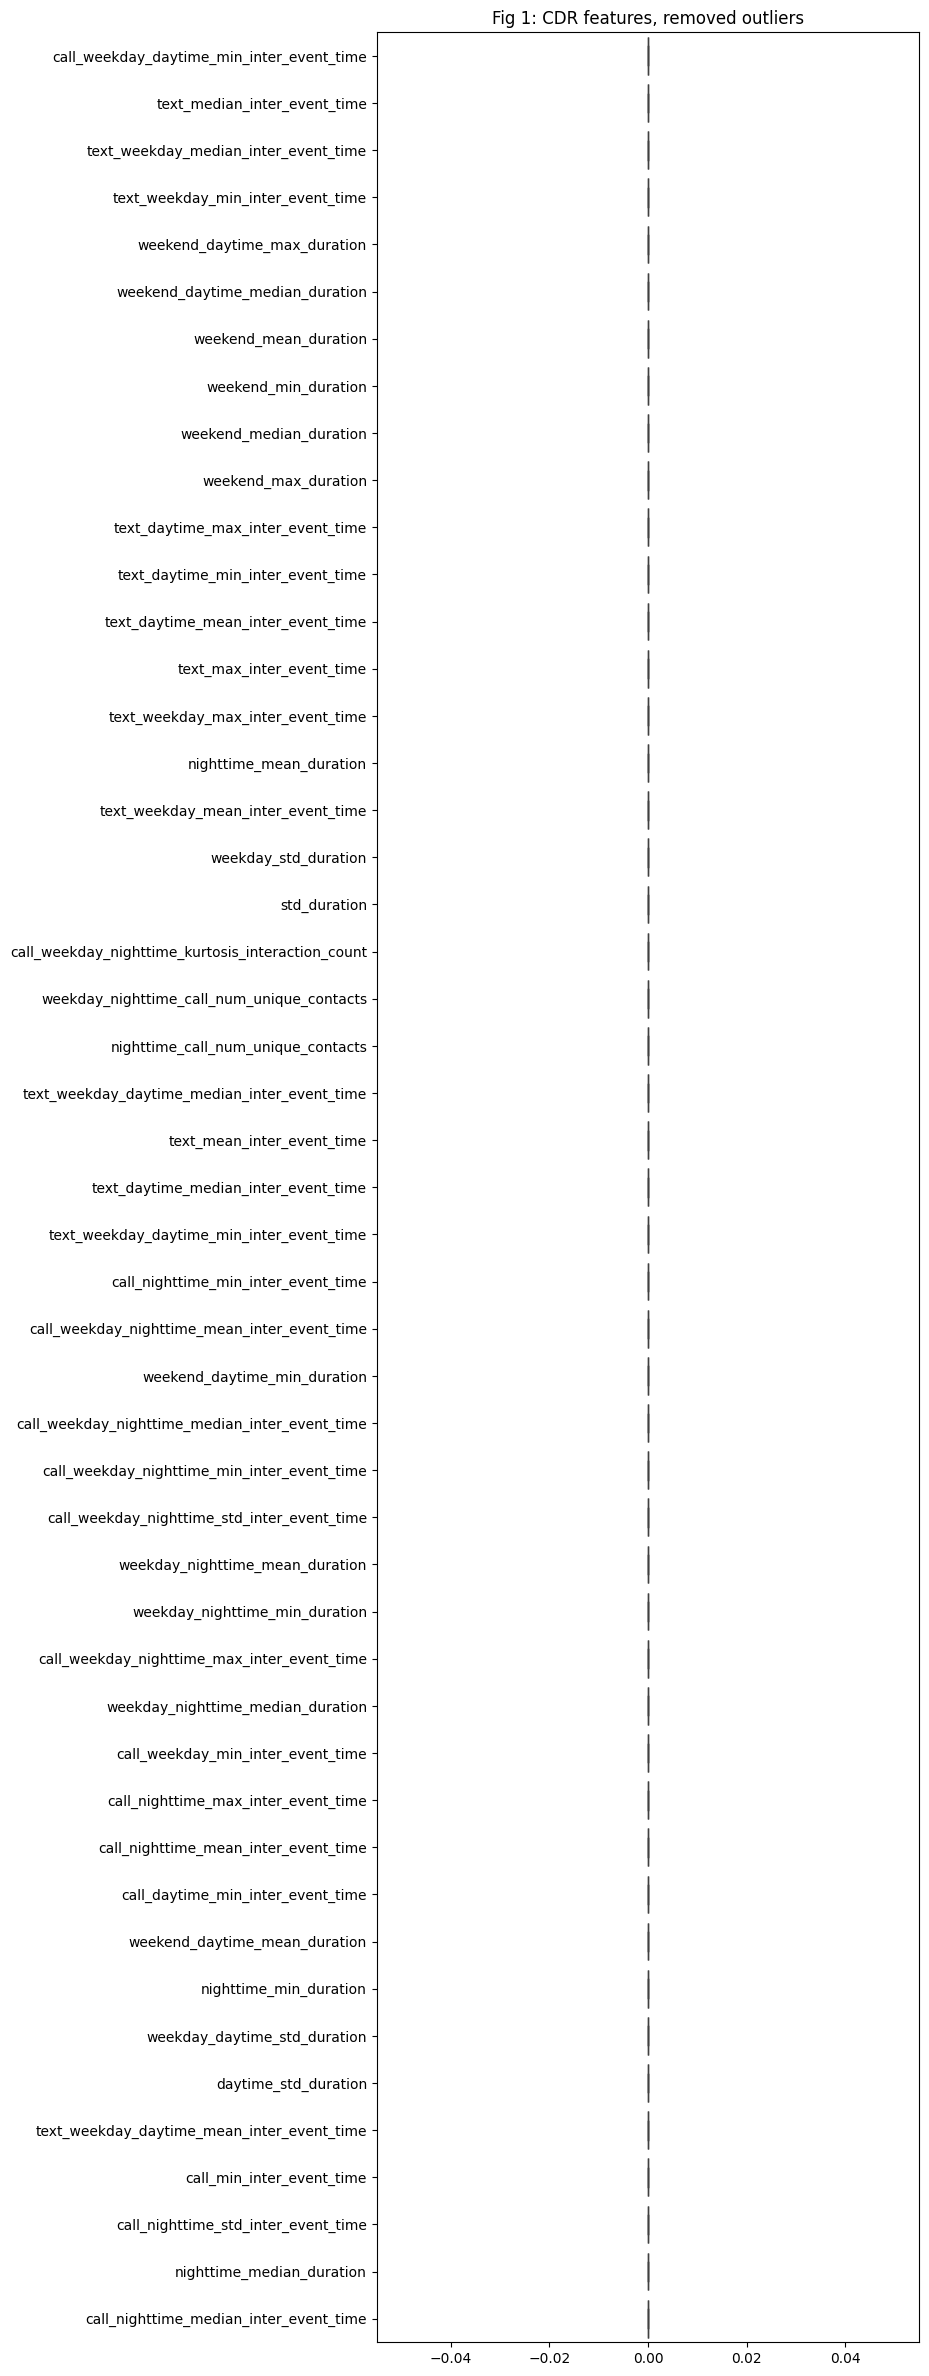

In [ ]:
color = sns.color_palette("deep")[0]
plt.figure(figsize=(7, 30))
sns.boxplot(data=filt_merged_df[ordered[:49]], orient='h', order=ordered[:49], showfliers=False, color=color).set_title('Fig 1: CDR features, removed outliers')

Text(0.5, 1.0, 'Fig 2: CDR features, removed outliers')

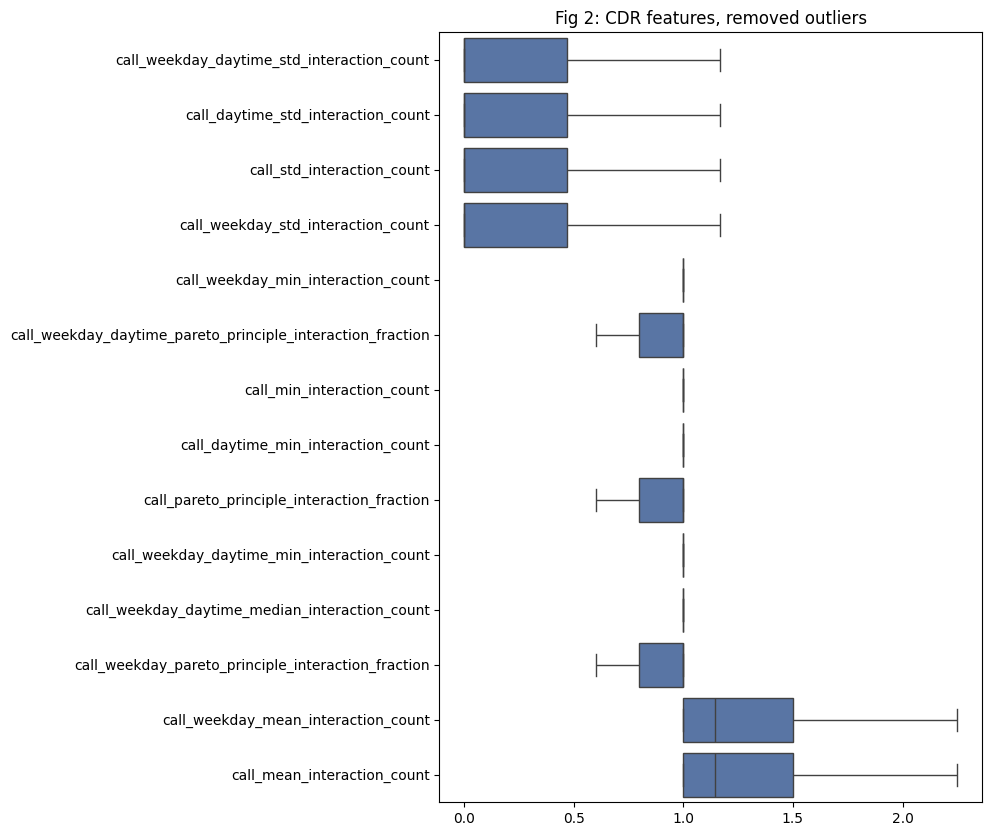

In [ ]:
plt.figure(figsize=(7, 10))
sns.boxplot(data=filt_merged_df[ordered[49:63]], orient='h', order=ordered[49:63], showfliers=False, color=color).set_title('Fig 2: CDR features, removed outliers')

Text(0.5, 1.0, 'Fig 3: CDR features, removed outliers')

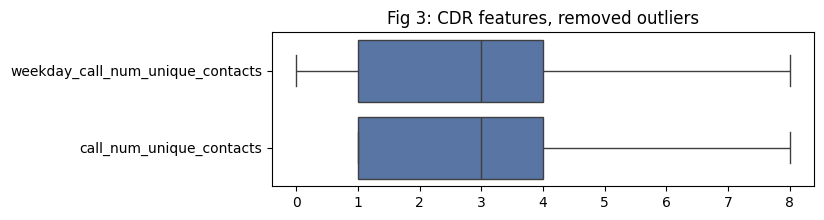

In [ ]:
plt.figure(figsize=(7, 2))
sns.boxplot(data=filt_merged_df[ordered[63:65]], orient='h', order=ordered[63:65], showfliers=False, color=color).set_title('Fig 3: CDR features, removed outliers')

Text(0.5, 1.0, 'Fig 4: CDR features, removed outliers')

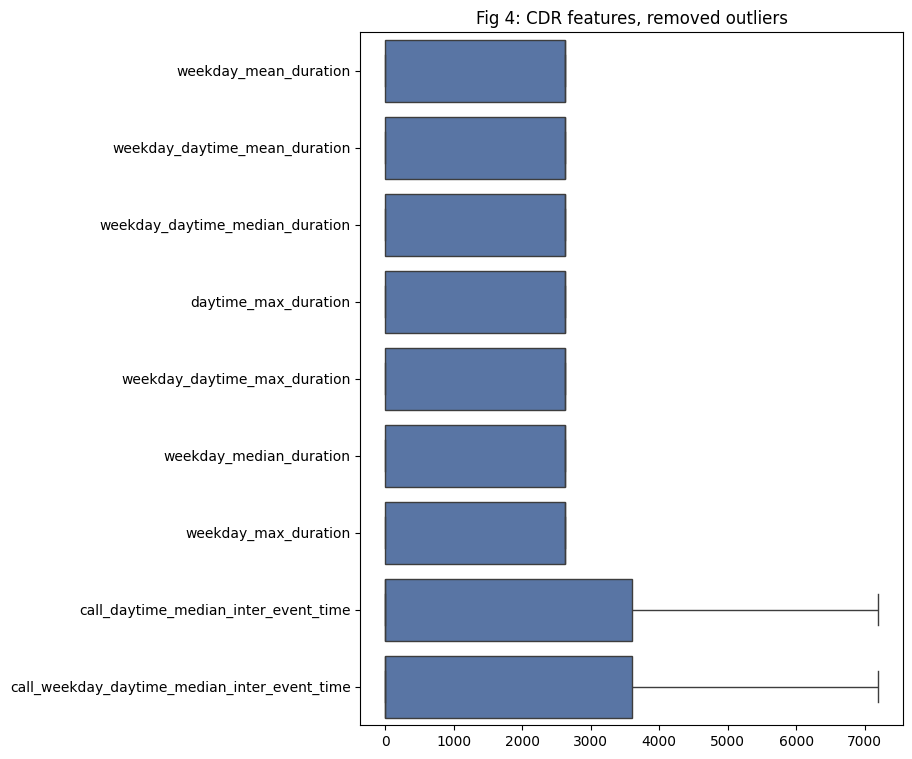

In [ ]:
plt.figure(figsize=(7, 9))
sns.boxplot(data=filt_merged_df[ordered[65:74]], orient='h', order=ordered[65:74], showfliers=False, color=color).set_title('Fig 4: CDR features, removed outliers')

Text(0.5, 1.0, 'Fig 5: CDR features, removed outliers')

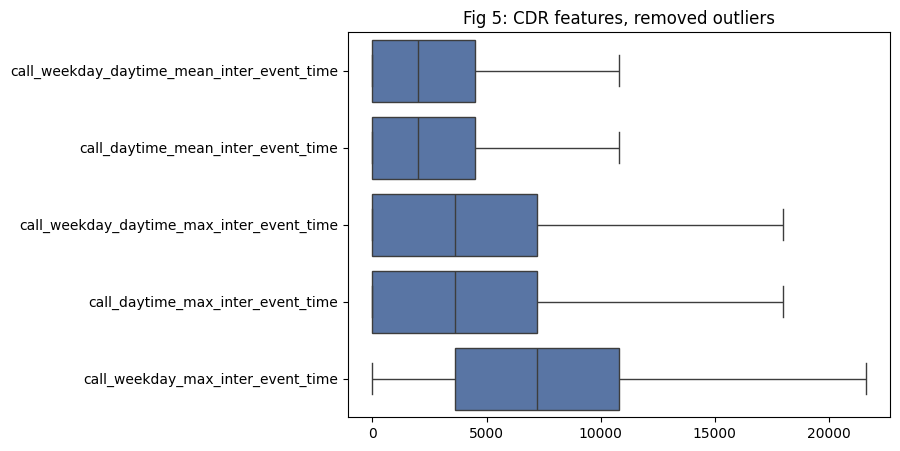

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=filt_merged_df[ordered[74:]], orient='h', order=ordered[74:], showfliers=False, color=color).set_title('Fig 5: CDR features, removed outliers')

### Mobile Money Features boxplots

In [206]:
ordered = list(filt_merged_df[mm_filtered_non_zero_var_features].describe().T.sort_values('50%', ascending=True).index)
plot_mm_df = filt_merged_df[ordered].copy()
plot_mm_df = plot_mm_df[plot_mm_df['std_balance_after']<1000]

Text(0.5, 1.0, 'Fig 1: Mobile Money features with nonzero variance')

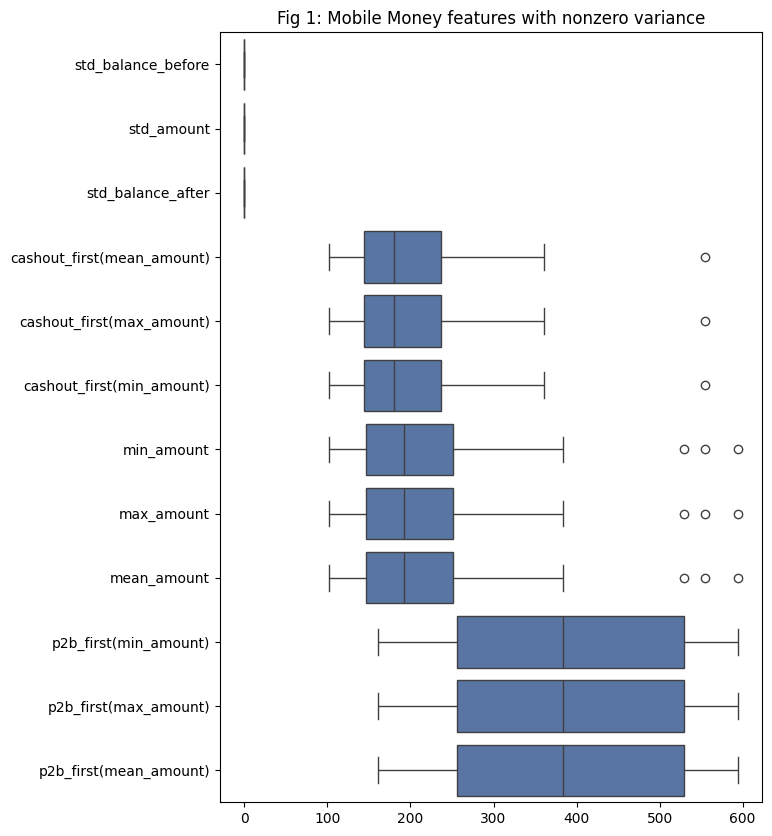

In [211]:
plt.figure(figsize=(7,10))
# sns.boxplot(data=filt_merged_df[ordered[:12]], orient='h', order=ordered[:12], showfliers=True).set_title('Boxplots of Mobile Money features with nonzero variance, ordered by median')
sns.boxplot(data=plot_mm_df[ordered[:12]], orient='h', order=ordered[:12], showfliers=True, color=color).set_title('Fig 1: Mobile Money features with nonzero variance')

Text(0.5, 1.0, 'Fig 2: Mobile Money features with nonzero variance')

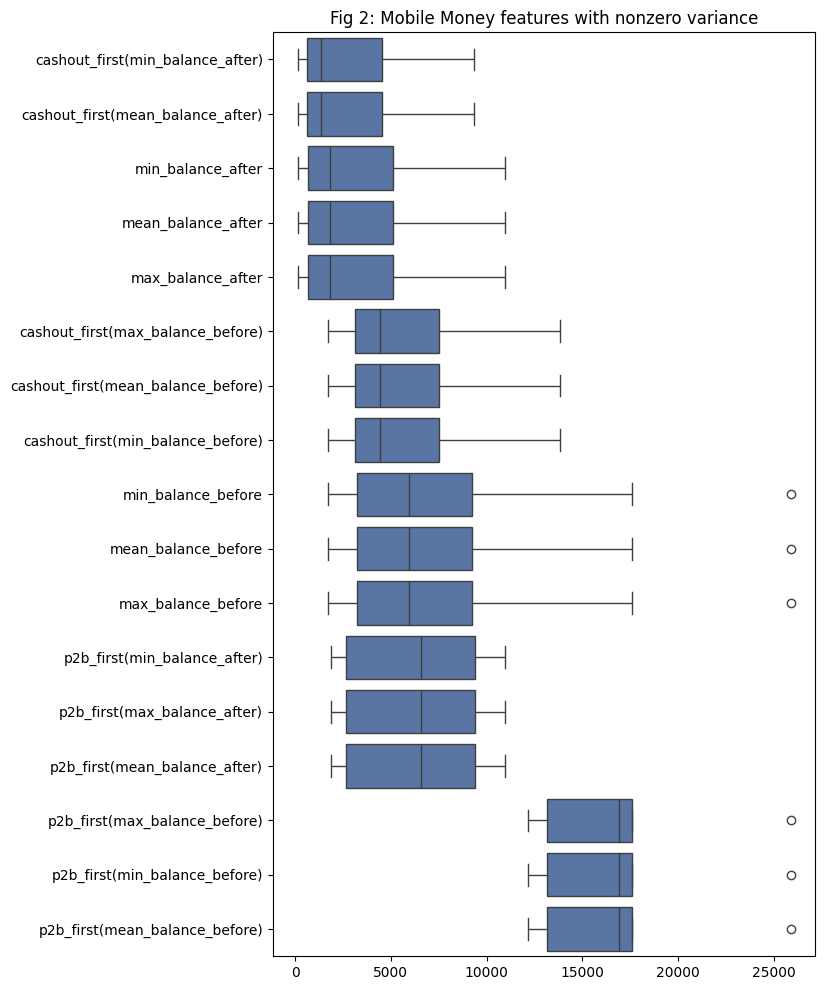

In [210]:
plt.figure(figsize=(7,12))
# sns.boxplot(data=filt_merged_df[ordered[:12]], orient='h', order=ordered[:12], showfliers=True).set_title('Boxplots of Mobile Money features with nonzero variance, ordered by median')
sns.boxplot(data=plot_mm_df[ordered[13:]], orient='h', order=ordered[13:], showfliers=True, color=color).set_title('Fig 2: Mobile Money features with nonzero variance')

### Correlation matrix between selected features

In [ ]:
all_selected_features = selected_features['cdr'] + mm_filtered_non_zero_var_features
corr_matrix_df = filt_merged_df[all_selected_features].corr().fillna(0)

In [217]:
plt.figure(figsize=(100, 100)) # Optional: Adjust the plot size
sns.heatmap(corr_matrix_df, 
            annot=True,       # Display correlation coefficients on the cells
            cmap='coolwarm',  # Use a diverging color map
            fmt=".2f",        # Format the annotations to two decimal places
            linewidths=.5     # Add lines between cells
           )
plt.title("Correlation Heatmap of Selected CDR and Mobile Money Transaction Features")

Text(0.5, 1.0, 'Correlation Heatmap of Selected CDR and Mobile Money Transaction Features')

## Group correlated features together

For every pair of features, if correlation is > threshold, group the features together. Any other features correlated to any features in a group, will be grouped together. 

e.g A - B correlated, A - C correlated, {A, B C} will be a group.

Note that this can mean B - C will be in the same group, even if they don't have correlation > threshold. 

In [ ]:
caller_ids = set(malawi_synthetic_data[CallDataRecordData]['caller_id'].unique()).union(set(malawi_synthetic_data[MobileMoneyTransactionData]['caller_id'].unique()))
malawi_features_df[malawi_features_df['caller_id'].isin(caller_ids)]
corr_df = malawi_features_df.drop(columns='caller_id').corr().reset_index().rename(columns={'index': 'feature1'})

long_corr_df = pd.melt(corr_df, id_vars='feature1', value_vars=corr_df.columns, var_name='feature2', value_name='correlation', col_level=None, ignore_index=False)
long_corr_df = long_corr_df[long_corr_df['feature1'] != long_corr_df['feature2']].dropna(subset=['correlation']) # drop self correlation
long_corr_df.head(10)

In [ ]:

cdr_corr_matrix = malawi_cdr_features_df[list(cdr_filtered_non_zero_var_features)].corr() # The .corr() method calculates the pairwise correlation coefficients
# cdr_rounded_corr_matrix = round(cdr_corr_matrix, 2)

g = sns.clustermap(cdr_corr_matrix.fillna(0), 
                   cmap='coolwarm', 
                   vmin=-1, vmax=1,
                   figsize=(15, 15), # Large size is critical
                   xticklabels=False, # Labels often overlap at 299 features
                   yticklabels=False)
plt.show()

In [ ]:

mm_corr_matrix = malawi_mobile_money_features_df[list(mm_filtered_non_zero_var_features)].corr() # The .corr() method calculates the pairwise correlation coefficients
# mm_rounded_corr_matrix = round(mm_corr_matrix, 2)

g = sns.clustermap(mm_corr_matrix.fillna(0), 
                   cmap='coolwarm', 
                   vmin=-1, vmax=1,
                   figsize=(10, 10), # Large size is critical
                   xticklabels=True, # Labels often overlap at 299 features
                   yticklabels=True)
plt.show()

In [ ]:

def build_graph(df: pd.DataFrame, threshold: float):
    adj = defaultdict(set)

    # filter strong correlations
    strong = df[df["correlation"].abs() >= threshold]

    for _, row in strong.iterrows():
        f1 = row["feature1"]
        f2 = row["feature2"]

        # undirected graph (important!)
        adj[f1].add(f2)
        adj[f2].add(f1)

    return adj

def dfs(adj, root, visited):
    stack = [root]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            stack.extend(adj.get(node, []))

def group_correlated_features(df: pd.DataFrame, threshold: float):
    adj = build_graph(df, threshold)

    unexplored = set(adj.keys())
    groups = []

    while unexplored:
        root = next(iter(unexplored))
        component = set()

        dfs(adj, root, component)

        groups.append(component)
        unexplored -= component

    return groups

In [ ]:
# get groups of correlated features with correlation above 0.9
groups_of_correlated_features = group_correlated_features(long_corr_df, threshold=0.9)
print(len(groups_of_correlated_features))
groups_of_correlated_features

In [ ]:
test_features = ['daytime_text_entropy_of_interactions',
  'text_daytime_max_inter_event_time',
  'text_daytime_mean_inter_event_time',
  'text_daytime_median_inter_event_time',
  'text_daytime_min_inter_event_time',
  'text_entropy_of_interactions',
  'text_max_inter_event_time',
  'text_mean_inter_event_time',
  'text_median_inter_event_time',
  'text_min_inter_event_time',
  'text_weekday_daytime_max_inter_event_time',
  'text_weekday_daytime_mean_inter_event_time',
  'text_weekday_daytime_median_inter_event_time',
  'text_weekday_daytime_min_inter_event_time',
  'text_weekday_max_inter_event_time',
  'text_weekday_mean_inter_event_time',
  'text_weekday_median_inter_event_time',
  'text_weekday_min_inter_event_time',
  'weekday_daytime_text_entropy_of_interactions',
  'weekday_text_entropy_of_interactions']
malawi_features_df[test_features].corr()

In [ ]:
test_features = ['call_nighttime_median_inter_event_time',
  'call_nighttime_min_inter_event_time',
  'call_weekday_nighttime_median_inter_event_time',
  'call_weekday_nighttime_min_inter_event_time']
malawi_features_df[test_features].corr()

In [ ]:
malawi_features_df[['daytime_kurtosis_duration',
  'kurtosis_duration',
  'weekday_daytime_kurtosis_duration',
  'weekday_kurtosis_duration']].corr()

In [ ]:
test_features = ['call_daytime_incoming_num_interactions',
  'call_daytime_kurtosis_inter_event_time',
  'call_daytime_num_interactions',
  'call_daytime_skewness_inter_event_time',
  'call_incoming_num_interactions',
  'call_kurtosis_inter_event_time',
  'call_nighttime_incoming_num_interactions',
  'call_nighttime_num_interactions',
  'call_num_interactions',
  'call_num_unique_contacts',
  'call_skewness_inter_event_time',
  'call_weekday_daytime_incoming_num_interactions',
  'call_weekday_daytime_kurtosis_inter_event_time',
  'call_weekday_daytime_num_interactions',
  'call_weekday_daytime_skewness_inter_event_time',
  'call_weekday_incoming_num_interactions',
  'call_weekday_kurtosis_inter_event_time',
  'call_weekday_nighttime_incoming_num_interactions',
  'call_weekday_nighttime_num_interactions',
  'call_weekday_num_interactions',
  'call_weekday_skewness_inter_event_time',
  'cashout_first(max_amount)',
  'cashout_first(max_balance_after)',
  'cashout_first(max_balance_before)',
  'cashout_first(mean_amount)',
  'cashout_first(mean_balance_after)',
  'cashout_first(mean_balance_before)',
  'cashout_first(min_amount)',
  'cashout_first(min_balance_after)',
  'cashout_first(min_balance_before)',
  'cashout_first(num_transactions)',
  'cashout_first(num_unique_correspondents)',
  'cashout_first(std_amount)',
  'daytime_call_num_unique_contacts',
  'max_amount',
  'max_balance_after',
  'max_balance_before',
  'mean_amount',
  'mean_balance_after',
  'mean_balance_before',
  'min_amount',
  'min_balance_after',
  'min_balance_before',
  'nighttime_call_entropy_of_interactions',
  'nighttime_call_num_unique_contacts',
  'p2b_first(max_amount)',
  'p2b_first(max_balance_after)',
  'p2b_first(max_balance_before)',
  'p2b_first(mean_amount)',
  'p2b_first(mean_balance_after)',
  'p2b_first(mean_balance_before)',
  'p2b_first(min_amount)',
  'p2b_first(min_balance_after)',
  'p2b_first(min_balance_before)',
  'p2b_first(num_transactions)',
  'p2b_first(num_unique_correspondents)',
  'p2b_first(std_amount)',
  'weekday_call_num_unique_contacts',
  'weekday_daytime_call_num_unique_contacts',
  'weekday_nighttime_call_entropy_of_interactions',
  'weekday_nighttime_call_num_unique_contacts']
malawi_features_df[test_features].corr()

Above is an example of set with some features that may not be correlated with all other features in the set. 

## Lasso

### cdr features

In [25]:
filt_merged_df = merged_df[merged_df['caller_id'].notna()].copy()
filt_merged_df = filt_merged_df[filtered_non_zero_var_features + exclude_columns].copy()

In [26]:
X = filt_merged_df.copy().drop(columns = exclude_columns)
y = filt_merged_df['consumption']
print(X.shape)
print(y.shape)

(1021, 329)
(1021,)


In [27]:
cdr_features = malawi_cdr_features_df.drop(columns='caller_id').columns
# cdr features with nonzero variances and non-null values
X = filt_merged_df[cdr_features.intersection(filtered_non_zero_var_features)]
X = X.loc[:,X.std() > 0]
y_cdr = np.array(filt_merged_df.loc[X.index, 'consumption'])
# X = X.dropna(axis=1) # dropping features with null values since Lasso cannot handle nulls
temp = (X.isna().sum() / len(X)).reset_index(name='nulls')
cdr_keep_features = temp[temp['nulls'] < 0.2]['index'].tolist() # keep features with less than 20% null values
X = X[cdr_keep_features]
X = X.apply(lambda col: col.fillna(col.median()), axis=0) # impute remaining null values with median
X_scaled_cdr = RobustScaler().fit_transform(X)
print(X_scaled_cdr.shape)
print(y_cdr)

(1021, 271)
[1909.27352512 1407.46598054  839.53649192 ... 2289.30650202 1978.84227283
  747.84107423]


In [28]:

model = Lasso(alpha=10)
model.fit(X_scaled_cdr, y_cdr)

cdr_lasso_selected = X.columns[model.coef_ != 0]
print('Initial number of CDR features:', len(cdr_features.intersection(filtered_non_zero_var_features)))
print('Number of CDR features selected by Lasso:',len(cdr_lasso_selected))
list(cdr_lasso_selected)

Initial number of CDR features: 299
Number of CDR features selected by Lasso: 52


/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.180e+09, tolerance: 5.237e+05
  model = cd_fast.enet_coordinate_descent(


['call_num_unique_contacts',
 'weekday_call_num_unique_contacts',
 'weekday_nighttime_mean_duration',
 'weekday_nighttime_min_duration',
 'weekday_daytime_std_duration',
 'weekday_nighttime_median_duration',
 'nighttime_min_duration',
 'daytime_std_duration',
 'nighttime_median_duration',
 'weekday_mean_duration',
 'weekday_std_duration',
 'weekday_median_duration',
 'std_duration',
 'call_weekday_daytime_mean_interaction_count',
 'call_weekday_mean_interaction_count',
 'call_mean_interaction_count',
 'call_weekday_daytime_min_interaction_count',
 'call_weekday_daytime_median_interaction_count',
 'call_weekday_median_interaction_count',
 'call_median_interaction_count',
 'call_weekday_nighttime_skewness_interaction_count',
 'call_weekday_nighttime_kurtosis_interaction_count',
 'text_weekday_daytime_mean_inter_event_time',
 'call_weekday_nighttime_mean_inter_event_time',
 'call_weekday_daytime_mean_inter_event_time',
 'call_nighttime_mean_inter_event_time',
 'call_daytime_mean_inter_eve

In [119]:
# Linear regression with all features
X_train, X_test, y_train, y_test = train_test_split(X_scaled_cdr, y_cdr, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
model = LinearRegression()
model.fit(X_train, y_train)

r_squared = model.score(X_test, y_test)
adj_r_squared = 1 - (1 - r_squared) * ((X_test.shape[0] - 1) / (X_test.shape[0] -  X_test.shape[1] - 1))

print('R^2 on test set:', r_squared)
print('Adjusted R^2 on test set:', adj_r_squared)
print('Mean absolute error on test set:', np.mean(np.abs(model.predict(X_test) - y_test)))
print('Mean absolute percentage error on test set:', np.mean(np.abs(model.predict(X_test) - y_test) / y_test))

(816, 271)
(205, 271)
R^2 on test set: -0.05001643889563012
Adjusted R^2 on test set: 4.197064978129978
Mean absolute error on test set: 1644.3668546440308
Mean absolute percentage error on test set: 1.0671997023157058


In [121]:
# Linear regression with chosen features
index_cdr_lasso_selected = [i for i, val in enumerate(X.columns) if val in list(cdr_lasso_selected)]
# X_scaled = [cdr_lasso_selected]
# X_train, X_test, y_train, y_test = train_test_split(X_scaled_cdr[:, index_cdr_lasso_selected], y_cdr, test_size=0.2, random_state=42)
X_train_filtered = X_train[:, index_cdr_lasso_selected].copy()
X_test_filtered = X_test[:, index_cdr_lasso_selected].copy()
print(X_train_filtered.shape)
print(X_test_filtered.shape)
model = LinearRegression()
model.fit(X_train_filtered, y_train)

r_squared = model.score(X_test_filtered, y_test)
adj_r_squared = 1 - (1 - r_squared) * ((X_test_filtered.shape[0] - 1) / (X_test_filtered.shape[0] -  X_test_filtered.shape[1] - 1))

print('R^2 on test set:', r_squared)
print('Adjusted R^2 on test set:', adj_r_squared)
print('Mean absolute error on test set:', np.mean(np.abs(model.predict(X_test_filtered) - y_test)))
print('Mean absolute percentage error on test set:', np.mean(np.abs(model.predict(X_test_filtered) - y_test) / y_test))

(816, 183)
(205, 183)
R^2 on test set: -0.0502153169313686
Adjusted R^2 on test set: -9.202091650190438
Mean absolute error on test set: 1644.8650202389283
Mean absolute percentage error on test set: 1.068552017184461


### mobile money features

In [42]:
mm_features = malawi_mobile_money_features_df.drop(columns='caller_id').columns
# mobile money features with nonzero variances and non-null values
X_mm = filt_merged_df[mm_features.intersection(filtered_non_zero_var_features)].copy()
X_mm = X_mm.loc[X_mm.notna().sum(axis=1) > 0]
X_mm = X_mm.loc[:, X_mm.std() > 0]

# find features with less than 20% null values
temp = (X_mm.isna().sum() / len(X_mm)).reset_index(name='nulls')
mm_keep_features = temp[temp['nulls'] < 0.2]['index'].tolist() 

# since Lasso cannot handle nulls, drop features with more than 20% null values and impute remaining null values with median
X_mm = X_mm[mm_keep_features]
X_mm = X_mm.apply(lambda col: col.fillna(0), axis=0) # impute remaining null values with median
y_mm = filt_merged_df.loc[X_mm.index, 'consumption']
X_scaled_mm = RobustScaler().fit_transform(X_mm)
X_scaled_mm

array([[ 0.83228983,  0.83228983,  0.83228983, ...,  0.        ,
         0.        ,  0.        ],
       [-0.53135912, -0.53135912, -0.53135912, ..., -0.70947105,
        -0.70947105,  0.        ],
       [ 0.6299826 ,  0.6299826 ,  0.6299826 , ...,  0.78802527,
         0.78802527,  0.        ],
       ...,
       [ 0.77478587,  0.77478587,  0.77478587, ..., -0.6045333 ,
        -0.6045333 ,  0.        ],
       [-0.05794989, -0.05794989, -0.05794989, ...,  0.66691601,
         0.66691601,  0.        ],
       [-0.41347042, -0.41347042, -0.41347042, ..., -0.66424404,
        -0.66424404,  0.        ]])

In [30]:
model = Lasso(alpha=0.01)
model.fit(X_scaled_mm, y_mm)

mm_lasso_selected = X_mm.columns[model.coef_ != 0]
print('Initial number of mobile money features:', len(mm_features.intersection(filtered_non_zero_var_features)))
print('Number of mobile money features selected by Lasso:',len(mm_lasso_selected))
list(mm_lasso_selected)

Initial number of mobile money features: 30
Number of mobile money features selected by Lasso: 17


['cashout_first(mean_amount)',
 'cashout_first(min_amount)',
 'mean_amount',
 'min_amount',
 'max_amount',
 'std_amount',
 'cashout_first(mean_balance_after)',
 'cashout_first(min_balance_after)',
 'cashout_first(max_balance_after)',
 'cashout_first(mean_balance_before)',
 'cashout_first(min_balance_before)',
 'cashout_first(max_balance_before)',
 'mean_balance_after',
 'min_balance_after',
 'std_balance_after',
 'mean_balance_before',
 'min_balance_before']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_mm, y_mm, test_size=0.2, random_state=42)

model = Lasso(alpha=0.01)
model.fit(X_train, y_train)

r_squared = model.score(X_test, y_test)
adj_r_squared = 1 - (1 - r_squared) * ((X_test.shape[0] - 1) / (X_test.shape[0] -  X_test.shape[1] - 1))

print('R^2 on test set:', r_squared)
print('Adjusted R^2 on test set:', adj_r_squared)
print('Mean absolute error on test set:', np.mean(np.abs(model.predict(X_test) - y_test)))
print('Mean absolute percentage error on test set:', np.mean(np.abs(model.predict(X_test) - y_test) / y_test))

R^2 on test set: 0.025375981395155844
Adjusted R^2 on test set: 1.8860218350953128
Mean absolute error on test set: 2059.590164062766
Mean absolute percentage error on test set: 0.6792152497457103


/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.087e+08, tolerance: 2.440e+04
  model = cd_fast.enet_coordinate_descent(


In [96]:
# Linear regression with all features
X_train, X_test, y_train, y_test = train_test_split(X_scaled_mm, y_mm, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
model = LinearRegression()
model.fit(X_train, y_train)

r_squared = model.score(X_test, y_test)
adj_r_squared = 1 - (1 - r_squared) * ((X_test.shape[0] - 1) / (X_test.shape[0] -  X_test.shape[1] - 1))

print('R^2 on test set:', r_squared)
print('Adjusted R^2 on test set:', adj_r_squared)
print('Mean absolute error on test set:', np.mean(np.abs(model.predict(X_test) - y_test)))
print('Mean squared error on test set:', np.mean((model.predict(X_test) - y_test)**2))
print('Mean absolute percentage error on test set:', np.mean(np.abs(model.predict(X_test) - y_test) / y_test))

(35, 21)
(16, 21)
R^2 on test set: 0.04556652811870321
Adjusted R^2 on test set: 3.386083679703242
Mean absolute error on test set: 2006.1040240625275
Mean squared error on test set: 11737922.667278256
Mean absolute percentage error on test set: 1.2147353019968161


In [97]:
# Linear regression with chosen features
index_mm_lasso_selected = [i for i, val in enumerate(X.columns) if val in list(mm_lasso_selected)]
# X_scaled = [cdr_lasso_selected]
X_train, X_test, y_train, y_test = train_test_split(X_scaled_mm[:, index_mm_lasso_selected], y_mm, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
model = LinearRegression()
model.fit(X_train, y_train)

r_squared = model.score(X_test, y_test)
adj_r_squared = 1 - (1 - r_squared) * ((X_test.shape[0] - 1) / (X_test.shape[0] -  X_test.shape[1] - 1))

print('Linear regression R^2 on test set:', r_squared)
print('Adjusted R^2 on test set:', adj_r_squared)
print('Mean absolute error on test set:', np.mean(np.abs(model.predict(X_test) - y_test)))
print('Mean squared error on test set:', np.mean((model.predict(X_test) - y_test)**2))
print('Mean absolute percentage error on test set:', np.mean(np.abs(model.predict(X_test) - y_test) / y_test))

(35, 17)
(16, 17)
Linear regression R^2 on test set: 0.04556652811870099
Adjusted R^2 on test set: 8.158251039109743
Mean absolute error on test set: 2006.1040240625043
Mean squared error on test set: 11737922.667278284
Mean absolute percentage error on test set: 1.214735301996805


## Choosing right lambda for lasso feature prioritization

k-fold to get predictive performance for each lambda choices and feature selection.


In [ ]:
def evaluation_metrics(X_test, y_test, model):
    r_squared = model.score(X_test, y_test)
    adj_r_squared = 1 - (1 - r_squared) * ((X_test.shape[0] - 1) / (X_test.shape[0] -  X_test.shape[1] - 1))
    # mean_abs_error = np.mean(np.abs(model.predict(X_test) - y_test))
    mean_squared_error = np.mean((model.predict(X_test) - y_test)**2)
    mean_abs_perc_error = np.mean(np.abs(model.predict(X_test) - y_test) / y_test)
    spearman_rho, spearman_pvalue = spearmanr(model.predict(X_test), y_test)
    return {'r_squared': r_squared, 
            'adj_r_squared': adj_r_squared, 
            # 'mean_abs_error': mean_abs_error, 
            'mean_squared_error': mean_squared_error,
            'mean_abs_perc_error': mean_abs_perc_error,
            'spearman_rho': spearman_rho,
            'spearman_pvalue': spearman_pvalue}

In [33]:
def run_kfold(X, y, k, model, random_state, features = None):
    '''
    df
    k: number of kfold
    feature_list: list of features used for model training
    y_feature: str name of target variable
    '''
    kfold=KFold(k, shuffle = True, random_state=random_state)
    train_k_eval_dict = {'r_squared':[],
                   'adj_r_squared':[],
                   'mean_squared_error':[],
                   'mean_abs_perc_error':[],
                   'spearman_rho':[],
                   'spearman_pvalue':[]}
    test_k_eval_dict = {'r_squared':[],
                   'adj_r_squared':[],
                   'mean_squared_error':[],
                   'mean_abs_perc_error':[],
                   'spearman_rho':[],
                   'spearman_pvalue':[]}
                  
    k_eval_means = {}
    num_of_features_selected = []
    features_selected_list = []
    model_coef_list = []

    for train_index, test_index in kfold.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]        
        model.fit(X_train, y_train)
        
        train_eval_dict = evaluation_metrics(X_train, y_train, model)
        test_eval_dict = evaluation_metrics(X_test, y_test, model)
        num_of_features = np.sum(model.coef_ != 0)
        features_selected = features[model.coef_ != 0].tolist() if features is not None else None
        model_coef = [coef for coef in model.coef_ if coef != 0]
        assert len(features_selected) == len(model_coef), "Number of features selected should match number of nonzero coefficients"
        
        num_of_features_selected.append(num_of_features)
        features_selected_list.append(features_selected)
        model_coef_list.append(model_coef)
        
        for i in train_eval_dict:
            train_k_eval_dict[i].append(train_eval_dict[i])
            test_k_eval_dict[i].append(test_eval_dict[i])


    for x in train_eval_dict:
        k_eval_means['mean_train_' + x] = np.mean(train_k_eval_dict[x], axis=0)
    for x in test_k_eval_dict:
        k_eval_means['mean_test_' + x] = np.mean(test_k_eval_dict[x], axis=0)
    k_eval_means['mean_num_of_features_selected'] = np.mean(num_of_features_selected)

    return {'train': train_k_eval_dict, 
            'test':test_k_eval_dict, 
            'mean':k_eval_means, 
            'num_of_features':num_of_features_selected, 
            'features_selected': features_selected_list, 
            'model_coef': model_coef_list}

In [ ]:
alpha_options = [0.001, 0.01, 0.1, 1, 10, 20, 35, 50, 70, 100, 125, 150, 175, 200]
cdr_kfold_results_df = pd.DataFrame(columns=['alpha', 'mean_train_r_squared', 'mean_train_adj_r_squared', 
                                         'mean_train_mean_squared_error', 'mean_train_mean_abs_perc_error', 'mean_test_r_squared', 
                                         'mean_test_adj_r_squared', 'mean_test_mean_squared_error', 'mean_test_mean_abs_perc_error', 
                                         'mean_test_spearman_rho', 'mean_test_spearman_pvalue',
                                         'mean_num_of_features_selected',  'features_selected', 'model_coef'])
for alpha in alpha_options:
    model = Lasso(alpha=alpha)
    kfold_results = run_kfold(X_scaled_cdr, np.array(y_cdr), k=5, model=model, random_state=100, features=X.columns)
    mean_results = kfold_results['mean']
    mean_results['alpha'] = alpha
    mean_results['features_selected'] = kfold_results['features_selected']
    mean_results['model_coef'] = kfold_results['model_coef']
    cdr_kfold_results_df.loc[len(cdr_kfold_results_df)] = mean_results
cdr_kfold_results_df

/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.134e+09, tolerance: 4.491e+05
  model = cd_fast.enet_coordinate_descent(
/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.243e+09, tolerance: 4.803e+05
  model = cd_fast.enet_coordinate_descent(
/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective 

,alpha,mean_train_r_squared,mean_train_adj_r_squared,mean_train_mean_squared_error,mean_train_mean_abs_perc_error,mean_test_r_squared,mean_test_adj_r_squared,mean_test_mean_squared_error,mean_test_mean_abs_perc_error,mean_num_of_features_selected,mean_test_spearman_rho,mean_test_spearman_pvalue,features_selected,model_coef
0,0.001,0.067347,-0.396587,4.796738e+06,1.072691,-0.155131,4.462583,5.713219e+06,1.199853,213.8,-0.046559,0.182517,"[[active_days_day, active_days_night, active_d...","[[-4755.390684209159, 5898.094624165795, 4896...."
1,0.010,0.067333,-0.396607,4.796806e+06,1.072646,-0.152236,4.453769,5.702888e+06,1.199602,171.2,-0.046452,0.181649,"[[active_days_day, active_days_night, active_d...","[[-4008.1304256759286, 5963.014123912056, 4198..."
2,0.100,0.067218,-0.396779,4.797396e+06,1.072107,-0.136224,4.405218,5.647874e+06,1.195352,142.8,-0.041237,0.200150,"[[active_days_night, weekday_nighttime_call_nu...","[[5837.13890948053, 552.7106557051774, 971.530..."
3,1.000,0.061895,-0.404750,4.823622e+06,1.069445,-0.090505,4.267819,5.464482e+06,1.153680,119.0,-0.020869,0.267441,"[[active_days_day, active_days_night, weekday_...","[[50.668084754072254, 383.20280717731237, 639...."
4,10.000,0.037346,-0.441511,4.943502e+06,1.069676,-0.044416,4.129615,5.285812e+06,1.109094,58.8,0.011665,0.563457,"[[call_num_unique_contacts, weekday_call_num_u...","[[-92.44821322167296, -1.4348939329540394e-11,..."
5,20.000,0.024538,-0.460689,5.007740e+06,1.074863,-0.038040,4.110832,5.259390e+06,1.103374,47.4,-0.016555,0.434616,"[[call_num_unique_contacts, weekday_call_num_u...","[[-58.61605959001788, -9.246211300562225e-12, ..."
6,35.000,0.017236,-0.471622,5.043691e+06,1.079815,-0.027384,4.078975,5.214989e+06,1.099728,38.8,-0.006630,0.293354,"[[weekday_nighttime_mean_duration, weekday_day...","[[0.11634094644705348, -64.34582683753973, 0.0..."
7,50.000,0.013130,-0.477770,5.063903e+06,1.083339,-0.020659,4.058840,5.189462e+06,1.096189,37.4,-0.007285,0.291314,"[[weekday_nighttime_mean_duration, weekday_nig...","[[0.11948000562644018, 0.0039938951855121065, ..."
8,70.000,0.010622,-0.481525,5.076645e+06,1.085243,-0.015808,4.044324,5.170471e+06,1.093729,35.8,0.013038,0.373141,"[[weekday_nighttime_mean_duration, weekday_nig...","[[0.12239641702362355, 0.0038538403982646637, ..."
9,100.000,0.009159,-0.483716,5.083574e+06,1.086046,-0.013295,4.036820,5.160072e+06,1.092704,29.8,0.025457,0.463602,"[[weekday_nighttime_mean_duration, weekday_nig...","[[0.12222535595677865, 0.0038586665934893273, ..."


In [47]:
cdr_features_selection = cdr_kfold_results_df[['alpha', 'features_selected']].explode('features_selected')
cdr_features_selection['fold'] = cdr_features_selection.groupby(['alpha']).ngroup() + 1
cdr_features_selection = cdr_features_selection.explode('features_selected')

# get model coefficiens for each feature in each fold and alpha
cdr_model_coef = cdr_kfold_results_df[['alpha', 'model_coef']].explode('model_coef')
cdr_model_coef['fold'] = cdr_model_coef.groupby(['alpha']).ngroup() + 1
cdr_model_coef = cdr_model_coef.explode('model_coef')
cdr_features_selection['model_coef'] = cdr_model_coef['model_coef'].values
cdr_features_selection


,alpha,features_selected,fold,model_coef
0,0.001,active_days_day,1,-4755.390684
0,0.001,active_days_night,1,5898.094624
0,0.001,active_days_weekday_day,1,4896.815548
0,0.001,active_days_weekday_night,1,650.625842
0,0.001,weekday_nighttime_call_num_unique_contacts,1,551.50956
...,...,...,...,...
13,200.000,call_nighttime_max_inter_event_time,14,-0.0
13,200.000,call_weekday_nighttime_std_inter_event_time,14,0.278386
13,200.000,call_nighttime_std_inter_event_time,14,0.0
13,200.000,call_weekday_nighttime_median_inter_event_time,14,-0.070194


In [48]:
cdr_features_alpha_agg = cdr_features_selection.groupby(['features_selected']).agg(num_occurence = ('alpha','count'), 
                                                                                   num_alpha_occurence = ('alpha', 'nunique'),
                                                                                   unique_alpha = ('alpha', 'unique')
                                                                                   ).reset_index()
print(cdr_features_alpha_agg.shape)
cdr_features_alpha_agg.sort_values('num_occurence', ascending=False).head(20)

(261, 4)


,features_selected,num_occurence,num_alpha_occurence,unique_alpha
94,call_weekday_nighttime_mean_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
237,weekday_nighttime_mean_duration,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
97,call_weekday_nighttime_median_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
91,call_weekday_nighttime_max_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
100,call_weekday_nighttime_min_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
86,call_weekday_min_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
72,call_weekday_daytime_min_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
107,call_weekday_nighttime_std_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
239,weekday_nighttime_min_duration,69,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
238,weekday_nighttime_median_duration,68,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."


In [91]:
cdr_features_alpha_agg[cdr_features_alpha_agg['num_alpha_occurence']==13]

,features_selected,num_occurence,num_alpha_occurence,unique_alpha
9,call_daytime_max_inter_event_time,46,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
18,call_daytime_min_inter_event_time,59,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
32,call_min_inter_event_time,51,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
37,call_nighttime_max_inter_event_time,62,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
40,call_nighttime_mean_inter_event_time,64,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
43,call_nighttime_median_inter_event_time,53,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
46,call_nighttime_min_inter_event_time,44,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
53,call_nighttime_std_inter_event_time,57,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
72,call_weekday_daytime_min_inter_event_time,65,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
86,call_weekday_min_inter_event_time,65,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."


Text(0.5, 0.98, 'Lasso Regression 5-Fold Performance on CDR Features')

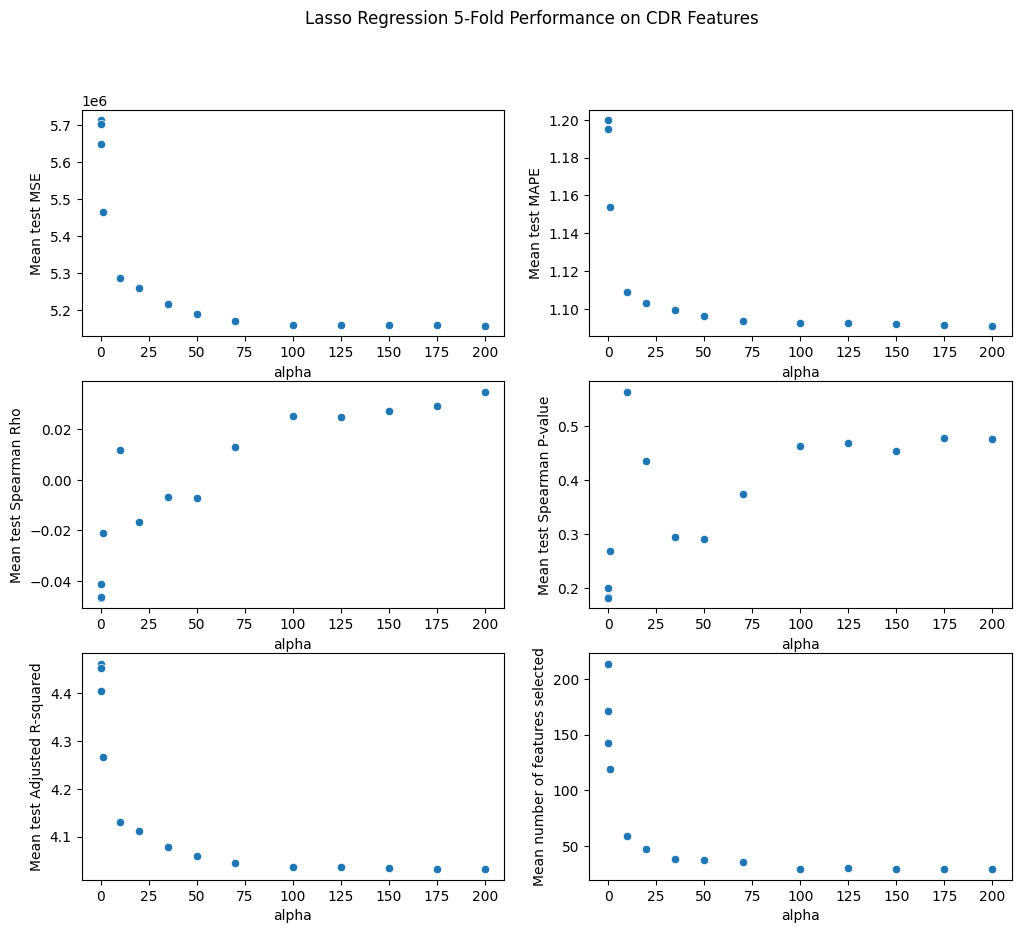

In [46]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
sns.scatterplot(data = cdr_kfold_results_df, x='alpha', y='mean_test_mean_squared_error', ax=axes[0,0]).set_ylabel('Mean test MSE')
sns.scatterplot(data = cdr_kfold_results_df, x='alpha', y='mean_test_mean_abs_perc_error', ax=axes[0,1]).set_ylabel('Mean test MAPE')
sns.scatterplot(data = cdr_kfold_results_df, x='alpha', y='mean_test_spearman_rho', ax=axes[1,0]).set_ylabel('Mean test Spearman Rho')
sns.scatterplot(data = cdr_kfold_results_df, x='alpha', y='mean_test_spearman_pvalue', ax=axes[1,1]).set_ylabel('Mean test Spearman P-value')
sns.scatterplot(data = cdr_kfold_results_df, x='alpha', y='mean_test_adj_r_squared', ax=axes[2,0]).set_ylabel('Mean test Adjusted R-squared')
sns.scatterplot(data = cdr_kfold_results_df, x='alpha', y='mean_num_of_features_selected', ax=axes[2,1]).set_ylabel('Mean number of features selected')
fig.suptitle('Lasso Regression 5-Fold Performance on CDR Features')


In [74]:
cdr_recommended_features = cdr_features_alpha_agg[cdr_features_alpha_agg['unique_alpha'].apply(lambda x: 35 in x)].sort_values(['num_alpha_occurence', 'num_occurence'], ascending=[False, False])
recommended_features_dict = {'cdr':cdr_recommended_features['features_selected'].tolist()}
cdr_recommended_features

,features_selected,num_occurence,num_alpha_occurence,unique_alpha
72,call_weekday_daytime_min_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
86,call_weekday_min_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
91,call_weekday_nighttime_max_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
94,call_weekday_nighttime_mean_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
97,call_weekday_nighttime_median_inter_event_time,70,14,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0, 50.0..."
...,...,...,...,...
230,weekday_mean_duration,19,7,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0]"
33,call_min_interaction_count,16,7,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 35.0]"
222,weekday_daytime_mean_duration,18,6,"[0.001, 0.01, 0.1, 1.0, 20.0, 35.0]"
229,weekday_max_duration,15,6,"[0.001, 0.01, 0.1, 1.0, 35.0, 50.0]"


In [50]:
cdr_kfold_results_df[['alpha', 'mean_test_r_squared', 'mean_test_adj_r_squared', 'mean_test_mean_squared_error', 'mean_test_mean_abs_perc_error', 'mean_num_of_features_selected']]

,alpha,mean_test_r_squared,mean_test_adj_r_squared,mean_test_mean_squared_error,mean_test_mean_abs_perc_error,mean_num_of_features_selected
0,0.001,-0.155131,4.462583,5.713219e+06,1.199853,213.8
1,0.010,-0.152236,4.453769,5.702888e+06,1.199602,171.2
2,0.100,-0.136224,4.405218,5.647874e+06,1.195352,142.8
3,1.000,-0.090505,4.267819,5.464482e+06,1.153680,119.0
4,10.000,-0.044416,4.129615,5.285812e+06,1.109094,58.8
5,20.000,-0.038040,4.110832,5.259390e+06,1.103374,47.4
6,35.000,-0.027384,4.078975,5.214989e+06,1.099728,38.8
7,50.000,-0.020659,4.058840,5.189462e+06,1.096189,37.4
8,70.000,-0.015808,4.044324,5.170471e+06,1.093729,35.8
9,100.000,-0.013295,4.036820,5.160072e+06,1.092704,29.8


In [43]:
alpha_options = [0.001, 0.01, 0.1, 1, 10, 20, 50, 70, 100, 125, 150, 175, 200]
mm_kfold_results_df = pd.DataFrame(columns=['alpha', 'mean_train_r_squared', 'mean_train_adj_r_squared', 
                                         'mean_train_mean_squared_error', 'mean_train_mean_abs_perc_error', 'mean_test_r_squared', 
                                         'mean_test_adj_r_squared', 'mean_test_mean_squared_error', 'mean_test_mean_abs_perc_error', 
                                         'mean_test_spearman_rho', 'mean_test_spearman_pvalue',
                                         'mean_num_of_features_selected', 'features_selected'])
for alpha in alpha_options:
    model = Lasso(alpha=alpha)
    kfold_results = run_kfold(X_scaled_mm, np.array(y_mm), k=5, model=model, random_state=100, features=X_mm.columns)
    mean_results = kfold_results['mean']
    mean_results['alpha'] = alpha
    mean_results['features_selected'] = kfold_results['features_selected']
    mm_kfold_results_df.loc[len(mm_kfold_results_df)] = mean_results
mm_kfold_results_df

/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.093e+08, tolerance: 2.454e+04
  model = cd_fast.enet_coordinate_descent(
/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.848e+08, tolerance: 4.271e+04
  model = cd_fast.enet_coordinate_descent(
/Users/vivianwong/Documents/idinsight/projects/GiveDirectly/cider/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective 

,alpha,mean_train_r_squared,mean_train_adj_r_squared,mean_train_mean_squared_error,mean_train_mean_abs_perc_error,mean_test_r_squared,mean_test_adj_r_squared,mean_test_mean_squared_error,mean_test_mean_abs_perc_error,mean_test_spearman_rho,mean_test_spearman_pvalue,mean_num_of_features_selected,features_selected
0,0.001,0.126027,-0.851059,7.475451e+06,1.097728,-0.633514,2.254358,8.733030e+06,1.355788,0.186667,0.617219,17.4,"[[cashout_first(mean_amount), cashout_first(mi..."
1,0.010,0.126027,-0.851059,7.475451e+06,1.097739,-0.633457,2.254309,8.732360e+06,1.355454,0.186667,0.617219,17.8,"[[cashout_first(mean_amount), cashout_first(mi..."
2,0.100,0.126026,-0.851060,7.475455e+06,1.097910,-0.632732,2.253697,8.723487e+06,1.350860,0.186667,0.617219,16.0,"[[cashout_first(mean_amount), mean_amount, max..."
3,1.000,0.125958,-0.851208,7.475878e+06,1.099877,-0.626699,2.248648,8.654333e+06,1.319047,0.188485,0.613011,14.6,"[[cashout_first(mean_amount), cashout_first(mi..."
4,10.000,0.125067,-0.853101,7.481677e+06,1.110198,-0.595443,2.224995,8.544232e+06,1.268764,0.296970,0.435994,12.8,"[[cashout_first(mean_amount), cashout_first(mi..."
5,20.000,0.124677,-0.853927,7.484846e+06,1.113029,-0.571901,2.207376,8.526715e+06,1.260944,0.306061,0.409045,9.8,"[[cashout_first(mean_amount), cashout_first(mi..."
6,50.000,0.122831,-0.857840,7.500205e+06,1.117674,-0.503033,2.155806,8.466712e+06,1.240207,0.286667,0.434606,8.6,"[[mean_amount, cashout_first(mean_balance_afte..."
7,70.000,0.120988,-0.861751,7.515201e+06,1.120756,-0.463775,2.126435,8.432464e+06,1.228386,0.286667,0.409056,8.4,"[[mean_amount, cashout_first(mean_balance_afte..."
8,100.000,0.117723,-0.868662,7.542743e+06,1.126179,-0.412710,2.088353,8.401571e+06,1.225611,0.286667,0.407124,6.2,"[[cashout_first(mean_balance_before), cashout_..."
9,125.000,0.114666,-0.875130,7.569073e+06,1.129806,-0.376393,2.061304,8.378753e+06,1.226650,0.319394,0.361469,5.0,"[[cashout_first(mean_balance_before), min_bala..."


Text(0.5, 0.98, 'Lasso Regression 5-Fold Performance on Mobile Money Features')

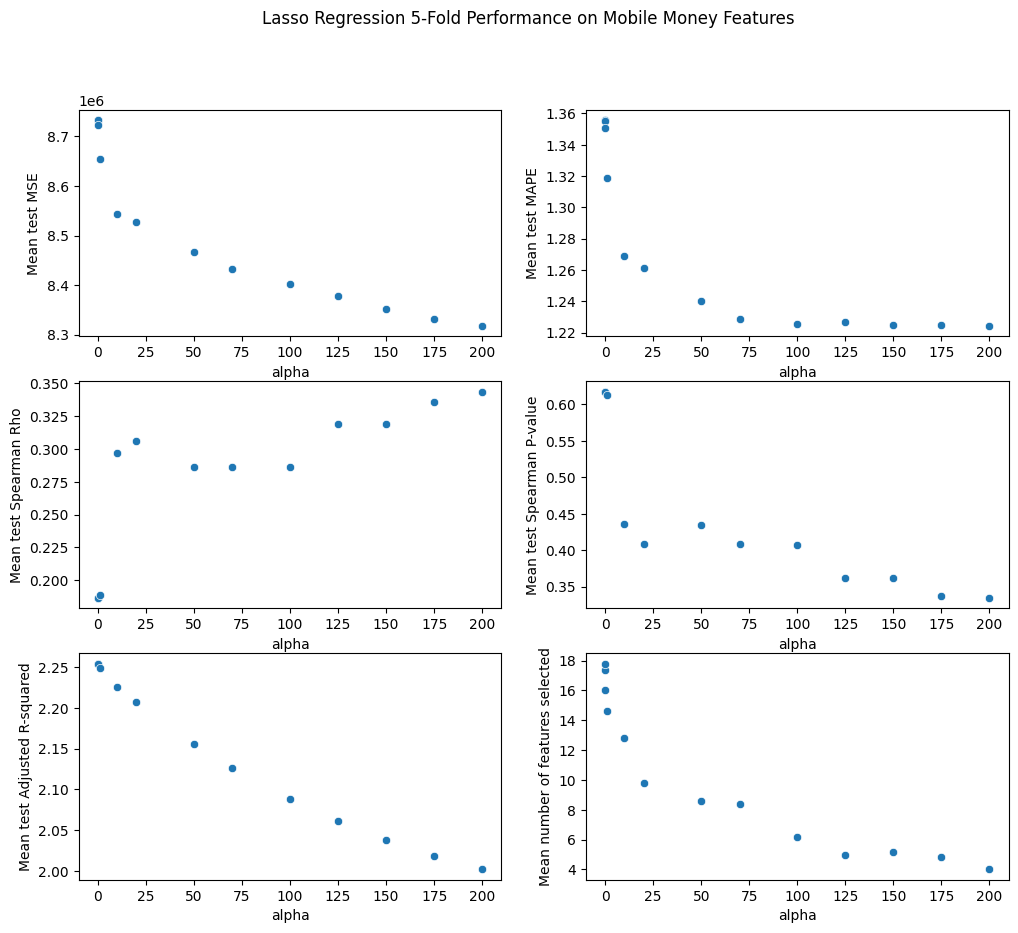

In [47]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
sns.scatterplot(data = mm_kfold_results_df, x='alpha', y='mean_test_mean_squared_error', ax=axes[0,0]).set_ylabel('Mean test MSE')
sns.scatterplot(data = mm_kfold_results_df, x='alpha', y='mean_test_mean_abs_perc_error', ax=axes[0,1]).set_ylabel('Mean test MAPE')
sns.scatterplot(data = mm_kfold_results_df, x='alpha', y='mean_test_spearman_rho', ax=axes[1,0]).set_ylabel('Mean test Spearman Rho')
sns.scatterplot(data = mm_kfold_results_df, x='alpha', y='mean_test_spearman_pvalue', ax=axes[1,1]).set_ylabel('Mean test Spearman P-value')
sns.scatterplot(data = mm_kfold_results_df, x='alpha', y='mean_test_adj_r_squared', ax=axes[2,0]).set_ylabel('Mean test Adjusted R-squared')
sns.scatterplot(data = mm_kfold_results_df, x='alpha', y='mean_num_of_features_selected', ax=axes[2,1]).set_ylabel('Mean number of features selected')
fig.suptitle('Lasso Regression 5-Fold Performance on Mobile Money Features')

In [52]:
mm_features_selection = mm_kfold_results_df[['alpha', 'features_selected']].explode('features_selected')
mm_features_selection['fold'] = mm_features_selection.groupby(['alpha']).ngroup() + 1
mm_features_selection = mm_features_selection.explode('features_selected')

mm_features_alpha_agg = mm_features_selection.groupby(['features_selected']).agg(num_occurence = ('alpha','count'), 
                                                                                   num_alpha_occurence = ('alpha', 'nunique'),
                                                                                   unique_alpha = ('alpha', 'unique')
                                                                                   ).reset_index()
mm_features_alpha_agg = mm_features_alpha_agg.sort_values(['num_alpha_occurence', 'num_occurence'], ascending=[False, False]).head(20)
mm_features_alpha_agg

,features_selected,num_occurence,num_alpha_occurence,unique_alpha
5,cashout_first(mean_balance_before),65,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
16,min_balance_after,57,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
19,std_balance_after,52,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
8,cashout_first(min_balance_before),51,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
4,cashout_first(mean_balance_after),49,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
2,cashout_first(max_balance_before),40,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
7,cashout_first(min_balance_after),34,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
1,cashout_first(max_balance_after),30,12,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
12,mean_amount,42,11,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
18,std_amount,24,9,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."


In [53]:
mm_features_alpha_agg[mm_features_alpha_agg['unique_alpha'].apply(lambda x: 70 in x)]

,features_selected,num_occurence,num_alpha_occurence,unique_alpha
5,cashout_first(mean_balance_before),65,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
16,min_balance_after,57,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
19,std_balance_after,52,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
8,cashout_first(min_balance_before),51,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
4,cashout_first(mean_balance_after),49,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
2,cashout_first(max_balance_before),40,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
7,cashout_first(min_balance_after),34,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
1,cashout_first(max_balance_after),30,12,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
12,mean_amount,42,11,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
18,std_amount,24,9,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."


In [54]:
mm_features_alpha_agg[mm_features_alpha_agg['num_alpha_occurence']==13]

,features_selected,num_occurence,num_alpha_occurence,unique_alpha
5,cashout_first(mean_balance_before),65,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
16,min_balance_after,57,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
19,std_balance_after,52,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
8,cashout_first(min_balance_before),51,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
4,cashout_first(mean_balance_after),49,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
2,cashout_first(max_balance_before),40,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."
7,cashout_first(min_balance_after),34,13,"[0.001, 0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 70.0..."


In [ ]:
mm_features_alpha_agg.sort_values()

In [83]:
mm_recommended_features = mm_features_alpha_agg.sort_values(['num_alpha_occurence', 'num_occurence'], ascending=[False, False])['features_selected'].tolist()
disregarded_mm_features = [feature for feature in malawi_mobile_money_features_df.drop(columns='caller_id').columns if feature not in mm_recommended_features]

recommended_features_dict = {'cdr':cdr_recommended_features['features_selected'].tolist(), 'mobile_money_transaction': mm_recommended_features + disregarded_mm_features}
print('Recommended CDR features:', len(recommended_features_dict['cdr']))
print('Recommended Mobile Money features:', len(recommended_features_dict['mobile_money_transaction']))

Recommended CDR features: 79
Recommended Mobile Money features: 40


In [ ]:
path = os.path.expanduser('~/Documents/idinsight/projects/GiveDirectly/synthetic_data_analysis/')
with open(os.path.join(path, 'recommended_features.json'), 'w') as f:
    json.dump(recommended_features_dict, f, indent=4)

# Appendix: latency checks

In [ ]:

# Run featurizer pipeline with latency check
profiler = Profiler()
with profiler:
    # Infer home locations
    homes_df = get_home_locations(
        cdr_data=synthetic_data[CallDataRecordData],
        antenna_data=synthetic_data[AntennaData],
        shapefile_data=shapefile_gdf,
        geographic_unit=geographic_unit,
        algorithm=algorithm,
        additional_columns_to_keep=[],
    )

    # Merge home locations with antenna data for plotting
    homes_with_antenna_df = homes_df.merge(
        synthetic_data[AntennaData],
        left_on="caller_antenna_id",
        right_on="antenna_id",
        how="left")

    # Convert to GeoDataFrame
    homes_with_antenna_gdf = gpd.GeoDataFrame(
        homes_with_antenna_df,
        geometry=gpd.points_from_xy(
            x=homes_with_antenna_df['longitude'],
            y=homes_with_antenna_df['latitude'])
    ).set_crs(epsg=4326)

    # Preprocess data: filtering, spammer removal, outlier day removal
    preprocessed_data = preprocess_data(
        data_dict=synthetic_data,
        filter_start_date=filter_start_date,
        filter_end_date=filter_end_date,
        spammer_threshold=spammer_threshold,
        outlier_day_z_score_threshold=outlier_day_z_score_threshold,
    )

    # Prepare antenna_data
    antenna_gdf = gpd.GeoDataFrame(
        synthetic_data[AntennaData],
        geometry=gpd.points_from_xy(
            x=synthetic_data[AntennaData]['longitude'],
            y=synthetic_data[AntennaData]['latitude'])
    ).set_crs(epsg=4326)
    antennas_merged_shp = gpd.sjoin(antenna_gdf, shapefile_gdf, how='left', predicate='within')[['antenna_id', 'region']]
    antennas_merged_shp.region.fillna('Unknown', inplace=True)
    antennas_df = antennas_merged_shp.merge(
        synthetic_data[AntennaData],
        on="antenna_id")

    preprocessed_data[AntennaData] = antennas_df

    # Featurize all data
    features_df = featurize_all_data(
        preprocessed_data=preprocessed_data,
        max_wait_for_convo_in_seconds=max_wait_for_convo_in_seconds,
        pareto_threshold=pareto_threshold,
    )